In [40]:
!pip install pandas openpyxl matplotlib scipy -q


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [25]:
import pandas as pd
df = pd.read_excel('sample.xlsx')

In [26]:
df.columns

Index(['Window_No', 'Start_SNo', 'End_SNo', 'ia_D1_Energy', 'ia_D2_Energy',
       'ia_D3_Energy', 'ia_D4_Energy', 'ib_D1_Energy', 'ib_D2_Energy',
       'ib_D3_Energy', 'ib_D4_Energy', 'ic_D1_Energy', 'ic_D2_Energy',
       'ic_D3_Energy', 'ic_D4_Energy', 'io_D1_Energy', 'io_D2_Energy',
       'io_D3_Energy', 'io_D4_Energy', 'i1_D1_Energy', 'i1_D2_Energy',
       'i1_D3_Energy', 'i1_D4_Energy', 'i2_D1_Energy', 'i2_D2_Energy',
       'i2_D3_Energy', 'i2_D4_Energy', 'va_D1_Energy', 'va_D2_Energy',
       'va_D3_Energy', 'va_D4_Energy', 'vb_D1_Energy', 'vb_D2_Energy',
       'vb_D3_Energy', 'vb_D4_Energy', 'vc_D1_Energy', 'vc_D2_Energy',
       'vc_D3_Energy', 'vc_D4_Energy', 'vo_D1_Energy', 'vo_D2_Energy',
       'vo_D3_Energy', 'vo_D4_Energy', 'v1_D1_Energy', 'v1_D2_Energy',
       'v1_D3_Energy', 'v1_D4_Energy', 'v2_D1_Energy', 'v2_D2_Energy',
       'v2_D3_Energy', 'v2_D4_Energy', 'Fault_Label'],
      dtype='str')

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 52 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Window_No     151 non-null    int64  
 1   Start_SNo     151 non-null    int64  
 2   End_SNo       151 non-null    int64  
 3   ia_D1_Energy  151 non-null    float64
 4   ia_D2_Energy  151 non-null    float64
 5   ia_D3_Energy  151 non-null    float64
 6   ia_D4_Energy  151 non-null    float64
 7   ib_D1_Energy  151 non-null    float64
 8   ib_D2_Energy  151 non-null    float64
 9   ib_D3_Energy  151 non-null    float64
 10  ib_D4_Energy  151 non-null    float64
 11  ic_D1_Energy  151 non-null    float64
 12  ic_D2_Energy  151 non-null    float64
 13  ic_D3_Energy  151 non-null    float64
 14  ic_D4_Energy  151 non-null    float64
 15  io_D1_Energy  151 non-null    float64
 16  io_D2_Energy  151 non-null    float64
 17  io_D3_Energy  151 non-null    float64
 18  io_D4_Energy  151 non-null    float64
 19

In [28]:
df.isna().sum()

Window_No       0
Start_SNo       0
End_SNo         0
ia_D1_Energy    0
ia_D2_Energy    0
ia_D3_Energy    0
ia_D4_Energy    0
ib_D1_Energy    0
ib_D2_Energy    0
ib_D3_Energy    0
ib_D4_Energy    0
ic_D1_Energy    0
ic_D2_Energy    0
ic_D3_Energy    0
ic_D4_Energy    0
io_D1_Energy    0
io_D2_Energy    0
io_D3_Energy    0
io_D4_Energy    0
i1_D1_Energy    0
i1_D2_Energy    0
i1_D3_Energy    0
i1_D4_Energy    0
i2_D1_Energy    0
i2_D2_Energy    0
i2_D3_Energy    0
i2_D4_Energy    0
va_D1_Energy    0
va_D2_Energy    0
va_D3_Energy    0
va_D4_Energy    0
vb_D1_Energy    0
vb_D2_Energy    0
vb_D3_Energy    0
vb_D4_Energy    0
vc_D1_Energy    0
vc_D2_Energy    0
vc_D3_Energy    0
vc_D4_Energy    0
vo_D1_Energy    0
vo_D2_Energy    0
vo_D3_Energy    0
vo_D4_Energy    0
v1_D1_Energy    0
v1_D2_Energy    0
v1_D3_Energy    0
v1_D4_Energy    0
v2_D1_Energy    0
v2_D2_Energy    0
v2_D3_Energy    0
v2_D4_Energy    0
Fault_Label     0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

# EDA — Target Label Analysis

## 1. Class Count Bar Chart

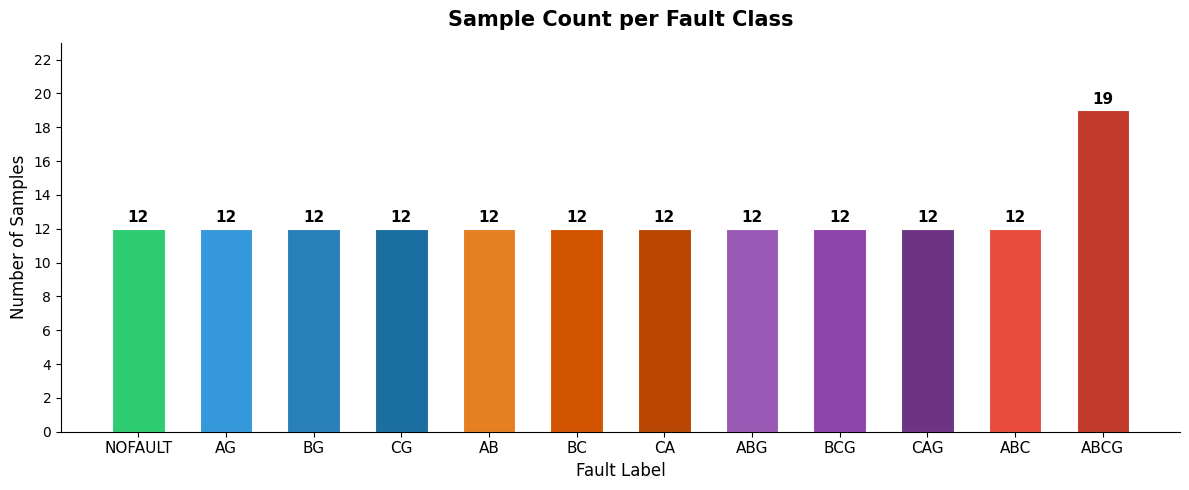

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fault_order = ['NOFAULT', 'AG', 'BG', 'CG', 'AB', 'BC', 'CA', 'ABG', 'BCG', 'CAG', 'ABC', 'ABCG']
color_map = {
    'NOFAULT': '#2ecc71',
    'AG': '#3498db', 'BG': '#2980b9', 'CG': '#1a6fa0',
    'AB': '#e67e22', 'BC': '#d35400', 'CA': '#b84600',
    'ABG': '#9b59b6', 'BCG': '#8e44ad', 'CAG': '#6c3483',
    'ABC': '#e74c3c', 'ABCG': '#c0392b'
}

class_counts = df['Fault_Label'].value_counts().reindex(fault_order)
colors = [color_map[f] for f in fault_order]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(fault_order, class_counts.values, color=colors, edgecolor='white', linewidth=0.8, width=0.6)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Sample Count per Fault Class', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Fault Label', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_ylim(0, class_counts.max() + 4)
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.show()

## 2. Class Percentage Table

Total samples: 151

   Fault_Label  Count  Percentage (%)
#                                    
1      NOFAULT     12            7.95
2           AG     12            7.95
3           BG     12            7.95
4           CG     12            7.95
5           AB     12            7.95
6           BC     12            7.95
7           CA     12            7.95
8          ABG     12            7.95
9          BCG     12            7.95
10         CAG     12            7.95
11         ABC     12            7.95
12        ABCG     19           12.58


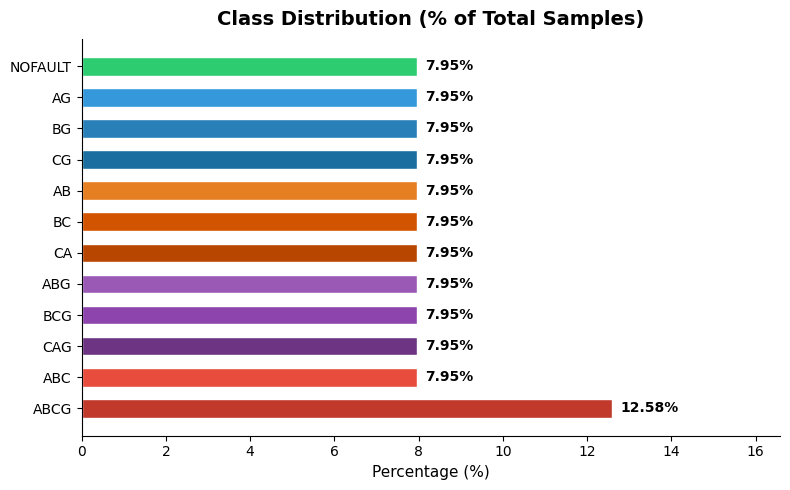

In [31]:
total = len(df)
class_counts_all = df['Fault_Label'].value_counts().reindex(fault_order)

pct_table = pd.DataFrame({
    'Fault_Label': fault_order,
    'Count': class_counts_all.values,
    'Percentage (%)': (class_counts_all.values / total * 100).round(2)
})
pct_table.index = range(1, len(pct_table) + 1)
pct_table.index.name = '#'

print(f"Total samples: {total}\n")
print(pct_table.to_string())

# Horizontal bar chart of percentages
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(fault_order[::-1], pct_table['Percentage (%)'].values[::-1],
               color=[color_map[f] for f in fault_order[::-1]], edgecolor='white', height=0.6)

for bar, pct in zip(bars, pct_table['Percentage (%)'].values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Class Distribution (% of Total Samples)', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Percentage (%)', fontsize=11)
ax.set_xlim(0, pct_table['Percentage (%)'].max() + 4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Grouped Label Categories

                  Group    Fault Types  Count  Percentage (%)
#                                                            
1                Normal        NOFAULT     12            7.95
2  Single-Phase\nGround     AG, BG, CG     36           23.84
3        Phase-to-Phase     AB, BC, CA     36           23.84
4  Double-Phase\nGround  ABG, BCG, CAG     36           23.84
5           Three-Phase      ABC, ABCG     31           20.53


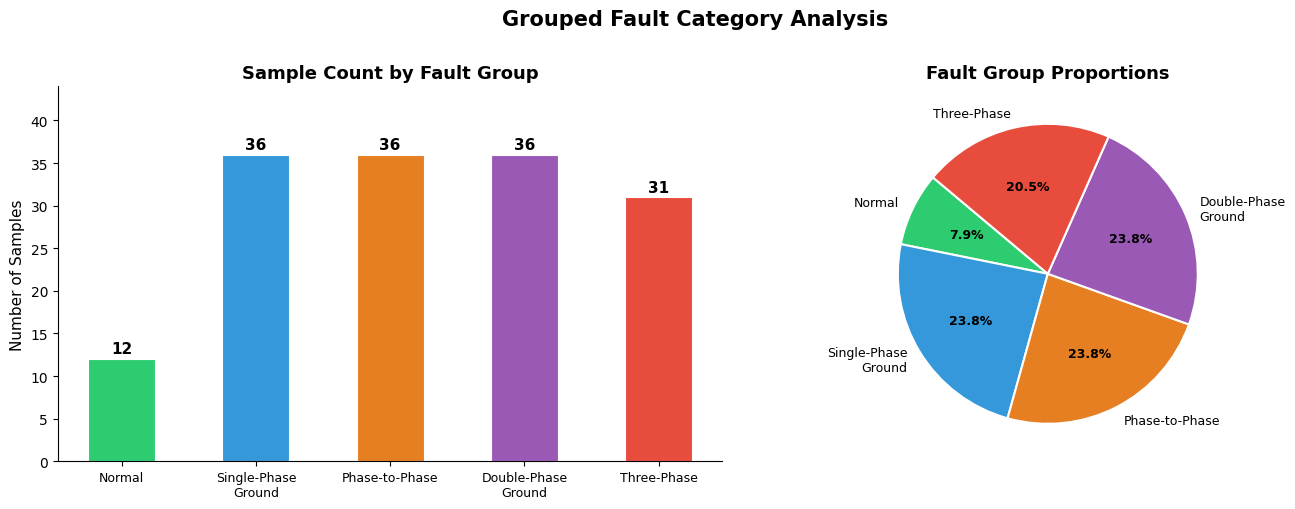

In [32]:
group_map = {
    'Normal':         ['NOFAULT'],
    'Single-Phase\nGround': ['AG', 'BG', 'CG'],
    'Phase-to-Phase': ['AB', 'BC', 'CA'],
    'Double-Phase\nGround': ['ABG', 'BCG', 'CAG'],
    'Three-Phase':    ['ABC', 'ABCG'],
}
group_colors = {
    'Normal': '#2ecc71',
    'Single-Phase\nGround': '#3498db',
    'Phase-to-Phase': '#e67e22',
    'Double-Phase\nGround': '#9b59b6',
    'Three-Phase': '#e74c3c',
}

group_counts = {g: df['Fault_Label'].isin(labels).sum() for g, labels in group_map.items()}
group_pct    = {g: round(c / total * 100, 2) for g, c in group_counts.items()}

group_df = pd.DataFrame({
    'Group': list(group_map.keys()),
    'Fault Types': [', '.join(v) for v in group_map.values()],
    'Count': list(group_counts.values()),
    'Percentage (%)': list(group_pct.values()),
})
group_df.index = range(1, len(group_df) + 1)
group_df.index.name = '#'
print(group_df.to_string())

# Side-by-side: grouped bar chart + pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

group_labels = list(group_map.keys())
g_colors = [group_colors[g] for g in group_labels]
g_counts  = [group_counts[g] for g in group_labels]

bars = ax1.bar(group_labels, g_counts, color=g_colors, edgecolor='white', linewidth=0.8, width=0.5)
for bar, cnt in zip(bars, g_counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(cnt), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Sample Count by Fault Group', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Samples', fontsize=11)
ax1.set_ylim(0, max(g_counts) + 8)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='x', labelsize=9)

wedges, texts, autotexts = ax2.pie(
    g_counts, labels=group_labels, colors=g_colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=9)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax2.set_title('Fault Group Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Grouped Fault Category Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# EDA — Descriptive Statistics

## 1. Global Statistics — All 48 Features

In [33]:
import numpy as np

feature_cols = [c for c in df.columns if c.endswith('_Energy')]

# Compute stats
stats = df[feature_cols].agg(['mean', 'std', 'min', 'max']).T
stats['Q1']     = df[feature_cols].quantile(0.25)
stats['Median'] = df[feature_cols].quantile(0.50)
stats['Q3']     = df[feature_cols].quantile(0.75)
stats['IQR']    = stats['Q3'] - stats['Q1']
stats = stats[['min', 'Q1', 'Median', 'mean', 'Q3', 'max', 'std', 'IQR']]
stats.columns   = ['Min', 'Q1 (25%)', 'Median', 'Mean', 'Q3 (75%)', 'Max', 'Std Dev', 'IQR']
stats.index.name = 'Feature'

pd.set_option('display.float_format', '{:.4e}'.format)
pd.set_option('display.max_rows', 60)
print(f"Global Descriptive Statistics — {len(feature_cols)} features × 151 samples\n")
print(stats.to_string())
pd.reset_option('display.float_format')

Global Descriptive Statistics — 48 features × 151 samples

                    Min   Q1 (25%)     Median       Mean   Q3 (75%)        Max    Std Dev        IQR
Feature                                                                                             
ia_D1_Energy 6.0137e-09 6.0188e-09 6.0189e-09 1.1387e-06 3.0507e-06 1.8720e-05 2.0331e-06 3.0447e-06
ia_D2_Energy 2.3351e-06 2.3351e-06 3.0634e-06 4.1613e-04 1.1836e-03 3.8874e-03 6.2199e-04 1.1813e-03
ia_D3_Energy 1.8370e-04 3.9081e-04 5.1270e-04 5.9186e-02 1.5519e-01 1.9809e-01 8.3100e-02 1.5480e-01
ia_D4_Energy 1.1990e-03 3.2720e-03 1.1914e+00 8.9581e-01 1.6583e+00 1.7803e+00 7.6339e-01 1.6550e+00
ib_D1_Energy 2.3219e-09 2.9810e-09 6.0188e-09 5.7056e-09 6.0189e-09 8.6069e-08 7.2507e-09 3.0379e-09
ib_D2_Energy 1.0975e-06 1.0976e-06 2.3351e-06 4.1998e-04 1.1836e-03 3.2014e-03 6.1308e-04 1.1825e-03
ib_D3_Energy 1.4847e-04 3.9081e-04 2.3793e-02 8.2692e-02 1.5519e-01 2.2037e-01 8.4580e-02 1.5480e-01
ib_D4_Energy 1.4287e-03 3.2718e-

## 2. Per-Class Statistics — Mean Energy per Feature grouped by Fault_Label

Mean Wavelet Energy per Fault Class

             ia_D1_Energy  ia_D2_Energy  ia_D3_Energy  ia_D4_Energy  ib_D1_Energy  ib_D2_Energy  ib_D3_Energy  ib_D4_Energy  ic_D1_Energy  ic_D2_Energy  ic_D3_Energy  ic_D4_Energy  io_D1_Energy  io_D2_Energy  io_D3_Energy  io_D4_Energy  i1_D1_Energy  i1_D2_Energy  i1_D3_Energy  i1_D4_Energy  i2_D1_Energy  i2_D2_Energy  i2_D3_Energy  i2_D4_Energy  va_D1_Energy  va_D2_Energy  va_D3_Energy  va_D4_Energy  vb_D1_Energy  vb_D2_Energy  vb_D3_Energy  vb_D4_Energy  vc_D1_Energy  vc_D2_Energy  vc_D3_Energy  vc_D4_Energy  vo_D1_Energy  vo_D2_Energy  vo_D3_Energy  vo_D4_Energy  v1_D1_Energy  v1_D2_Energy  v1_D3_Energy  v1_D4_Energy  v2_D1_Energy  v2_D2_Energy  v2_D3_Energy  v2_D4_Energy
Fault_Label                                                                                                                                                                                                                                                                            

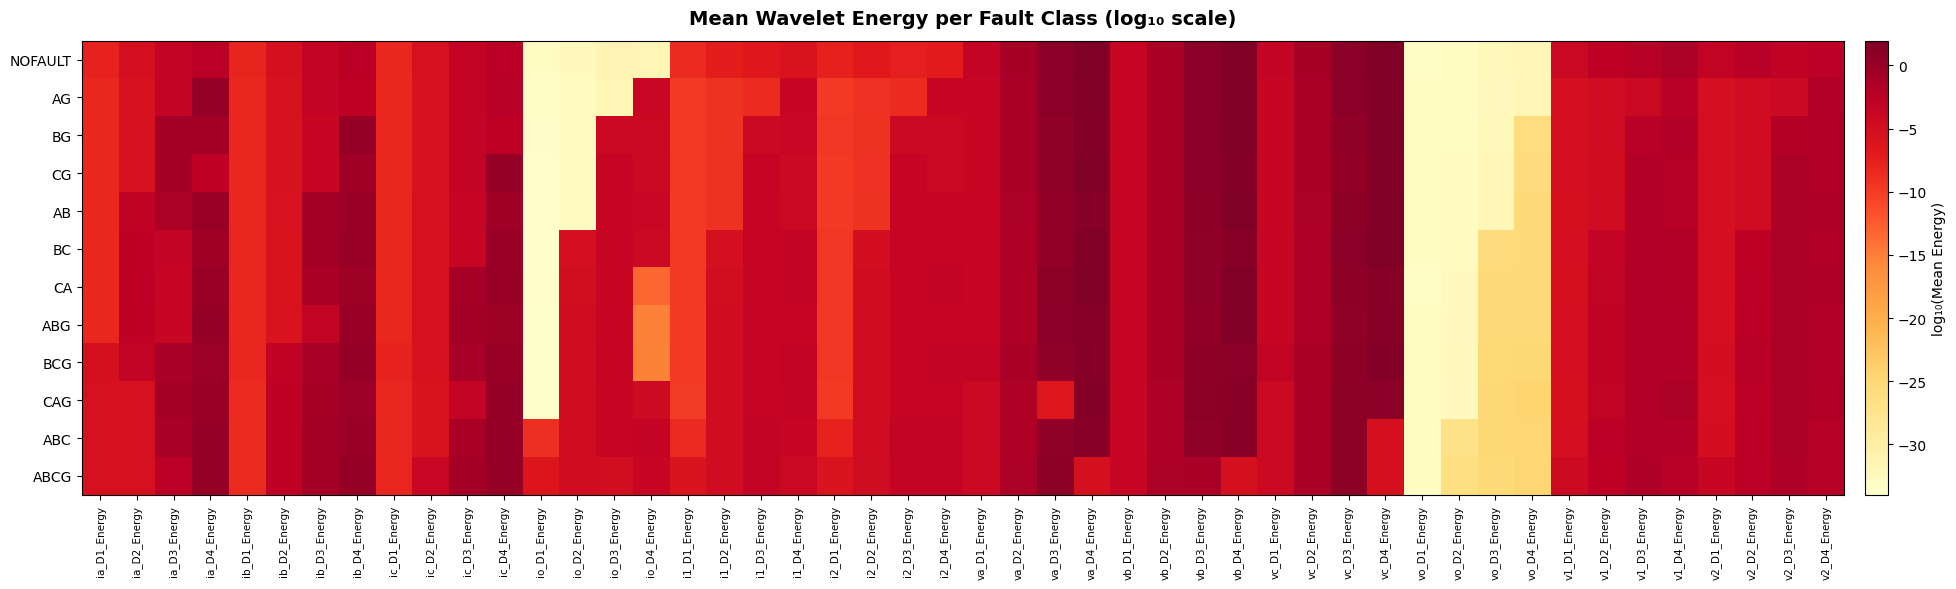

In [34]:
fault_order = ['NOFAULT', 'AG', 'BG', 'CG', 'AB', 'BC', 'CA', 'ABG', 'BCG', 'CAG', 'ABC', 'ABCG']

# Mean per class table
per_class_mean = df.groupby('Fault_Label')[feature_cols].mean().reindex(fault_order)
pd.set_option('display.float_format', '{:.4e}'.format)
print("Mean Wavelet Energy per Fault Class\n")
print(per_class_mean.to_string())
pd.reset_option('display.float_format')

# Heatmap: log-scaled mean energies (fault class × feature)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

log_mean = np.log10(per_class_mean.replace(0, np.nan))

fig, ax = plt.subplots(figsize=(22, 6))
im = ax.imshow(log_mean.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(fault_order)))
ax.set_yticklabels(fault_order, fontsize=10)

cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label('log₁₀(Mean Energy)', fontsize=10)

ax.set_title('Mean Wavelet Energy per Fault Class (log₁₀ scale)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 3. Energy Magnitude Range — D1 vs D2 vs D3 vs D4 Across All Signals

Mean energy by wavelet decomposition level (averaged across all signals):

Level         Mean Energy    Median Energy    Ratio vs D1
----------------------------------------------------------
D1             5.4793e-05       6.2059e-07            1.0x
D2             1.3576e-02       4.1805e-04          247.8x
D3             1.7003e+00       4.5103e-02        31031.6x
D4             9.3569e+00       4.5335e-01       170767.2x


/var/folders/m7/x79pvj7n0mxdf4v8ky2kds6h0000gn/T/ipykernel_4019/2561244006.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=levels, patch_artist=True, notch=False,


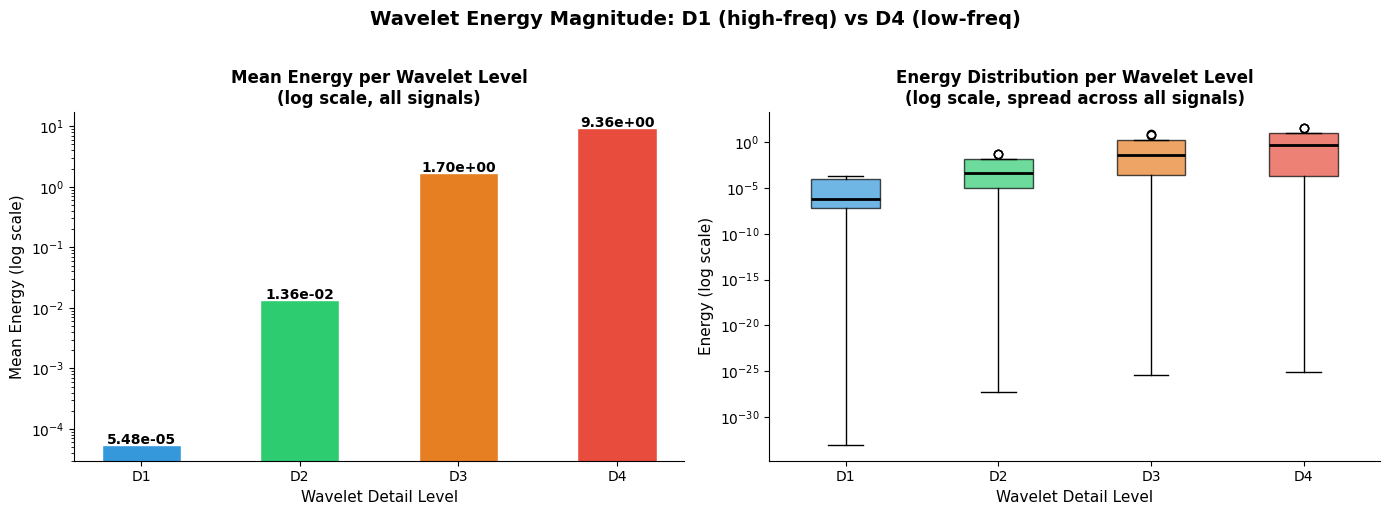

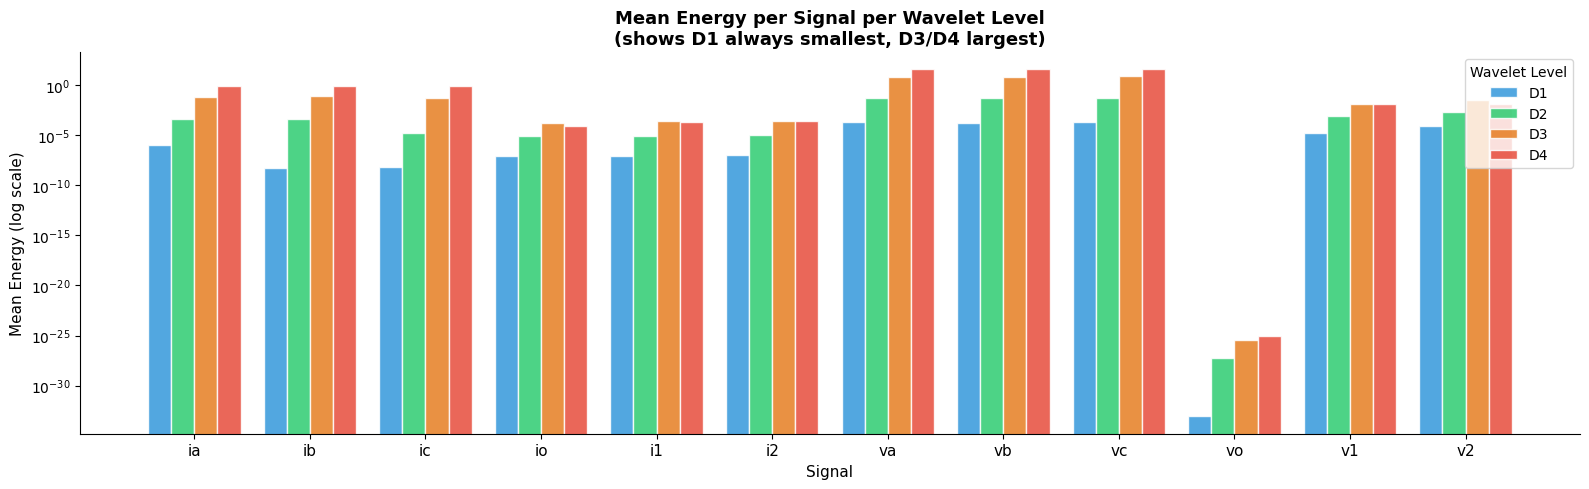

In [35]:
# Collect mean energy per wavelet level (D1–D4) across all signals
level_data = {'D1': [], 'D2': [], 'D3': [], 'D4': []}
for col in feature_cols:
    for level in level_data:
        if f'_{level}_' in col:
            level_data[level].append(df[col].mean())

level_means = {lvl: np.mean(vals) for lvl, vals in level_data.items()}
level_medians = {lvl: np.median(vals) for lvl, vals in level_data.items()}

print("Mean energy by wavelet decomposition level (averaged across all signals):\n")
print(f"{'Level':<8} {'Mean Energy':>16} {'Median Energy':>16} {'Ratio vs D1':>14}")
print("-" * 58)
d1_mean = level_means['D1']
for lvl in ['D1', 'D2', 'D3', 'D4']:
    ratio = level_means[lvl] / d1_mean
    print(f"{lvl:<8} {level_means[lvl]:>16.4e} {level_medians[lvl]:>16.4e} {ratio:>14.1f}x")

# --- Plot 1: Bar chart of mean energy per level ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

levels = ['D1', 'D2', 'D3', 'D4']
level_colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
means = [level_means[l] for l in levels]

axes[0].bar(levels, means, color=level_colors, edgecolor='white', width=0.5)
for i, (lvl, m) in enumerate(zip(levels, means)):
    axes[0].text(i, m * 1.05, f'{m:.2e}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_title('Mean Energy per Wavelet Level\n(log scale, all signals)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Energy (log scale)', fontsize=11)
axes[0].set_xlabel('Wavelet Detail Level', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Plot 2: Box plot per level showing distribution spread ---
box_data = [level_data[l] for l in levels]
bp = axes[1].boxplot(box_data, labels=levels, patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], level_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_yscale('log')
axes[1].set_title('Energy Distribution per Wavelet Level\n(log scale, spread across all signals)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Energy (log scale)', fontsize=11)
axes[1].set_xlabel('Wavelet Detail Level', fontsize=11)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Wavelet Energy Magnitude: D1 (high-freq) vs D4 (low-freq)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Plot 3: Grouped bar per signal (ia, ib, ic, io, i1, i2, va, vb, vc, vo, v1, v2) ---
signals = ['ia', 'ib', 'ic', 'io', 'i1', 'i2', 'va', 'vb', 'vc', 'vo', 'v1', 'v2']
x = np.arange(len(signals))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 5))
for i, (lvl, color) in enumerate(zip(levels, level_colors)):
    sig_means = [df[f'{s}_{lvl}_Energy'].mean() for s in signals]
    ax.bar(x + i * width, sig_means, width, label=lvl, color=color, alpha=0.85, edgecolor='white')

ax.set_yscale('log')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(signals, fontsize=11)
ax.set_title('Mean Energy per Signal per Wavelet Level\n(shows D1 always smallest, D3/D4 largest)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Energy (log scale)', fontsize=11)
ax.set_xlabel('Signal', fontsize=11)
ax.legend(title='Wavelet Level', fontsize=10, title_fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# EDA — Distribution Analysis

## 1. Raw Histograms — All 48 Features

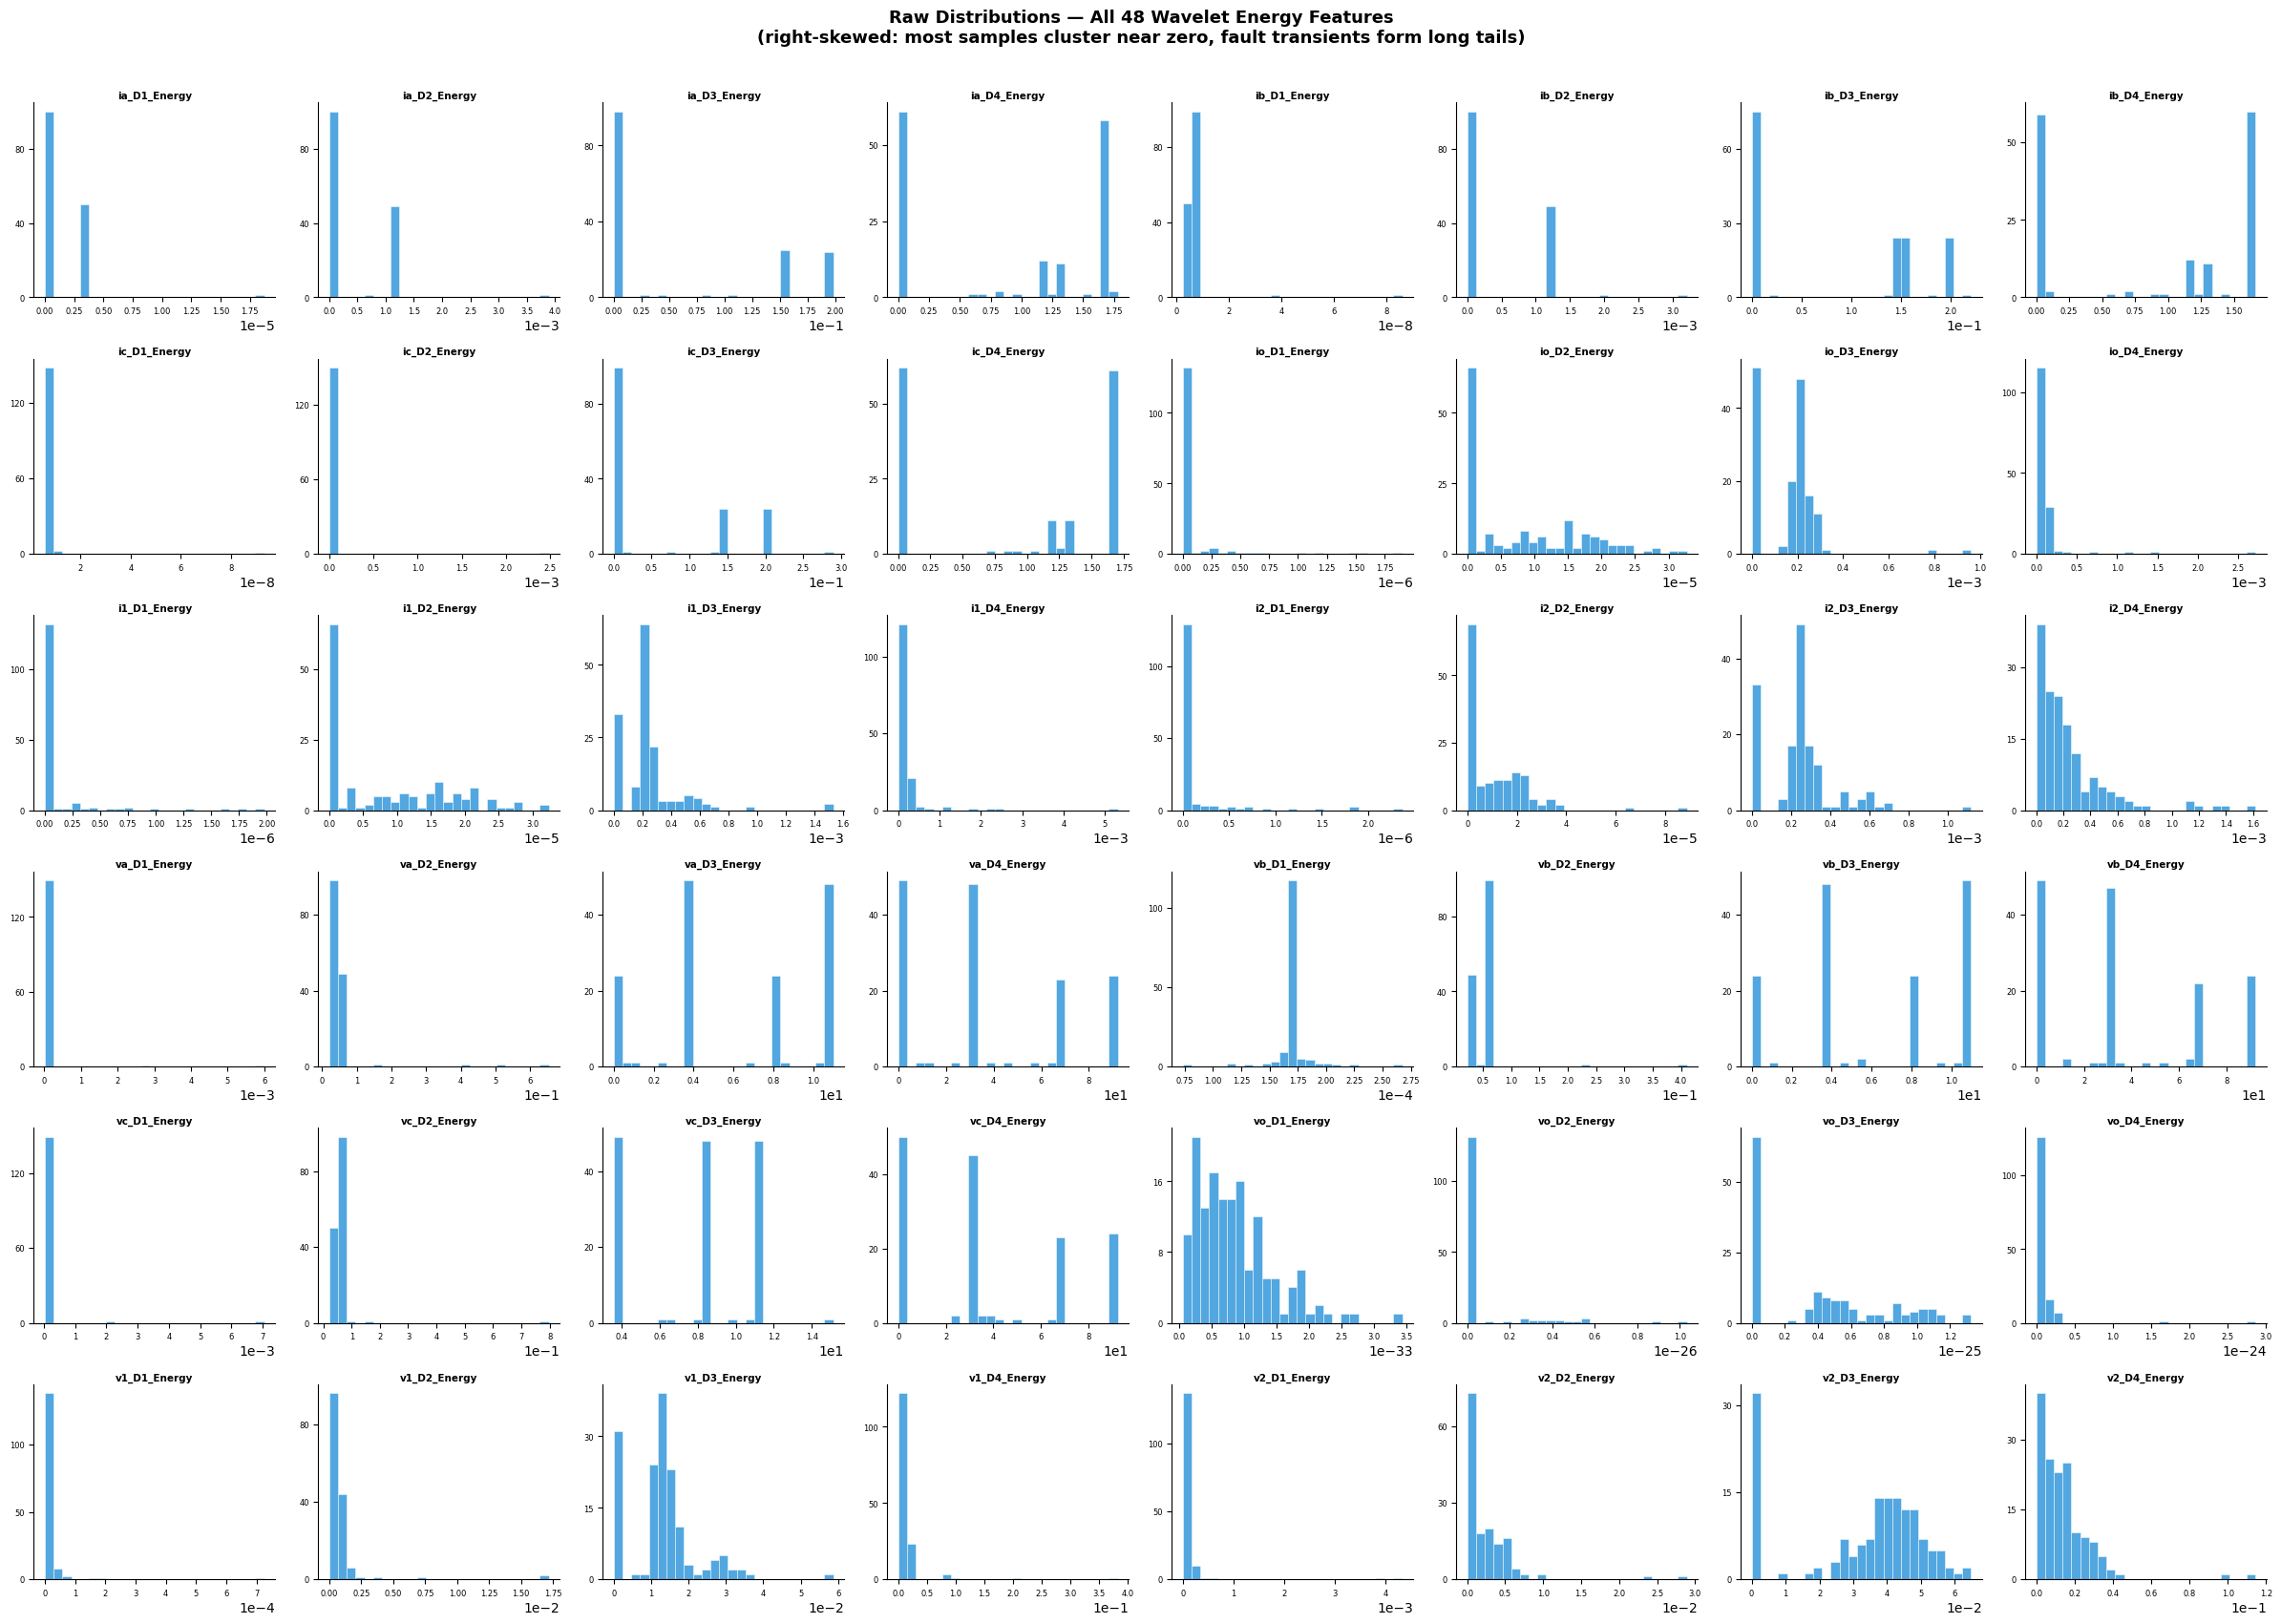

In [37]:
import matplotlib.pyplot as plt
import numpy as np

feature_cols = [c for c in df.columns if c.endswith('_Energy')]

n_cols = 8
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=25, color='#3498db', edgecolor='white', linewidth=0.4, alpha=0.85)
    axes[i].set_title(col, fontsize=7.5, fontweight='bold', pad=3)
    axes[i].tick_params(labelsize=6)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(3))
    # Format x-axis in scientific notation
    axes[i].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

# Hide unused axes
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Raw Distributions — All 48 Wavelet Energy Features\n(right-skewed: most samples cluster near zero, fault transients form long tails)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2. Log-Scale Histograms — log1p Transformed Features

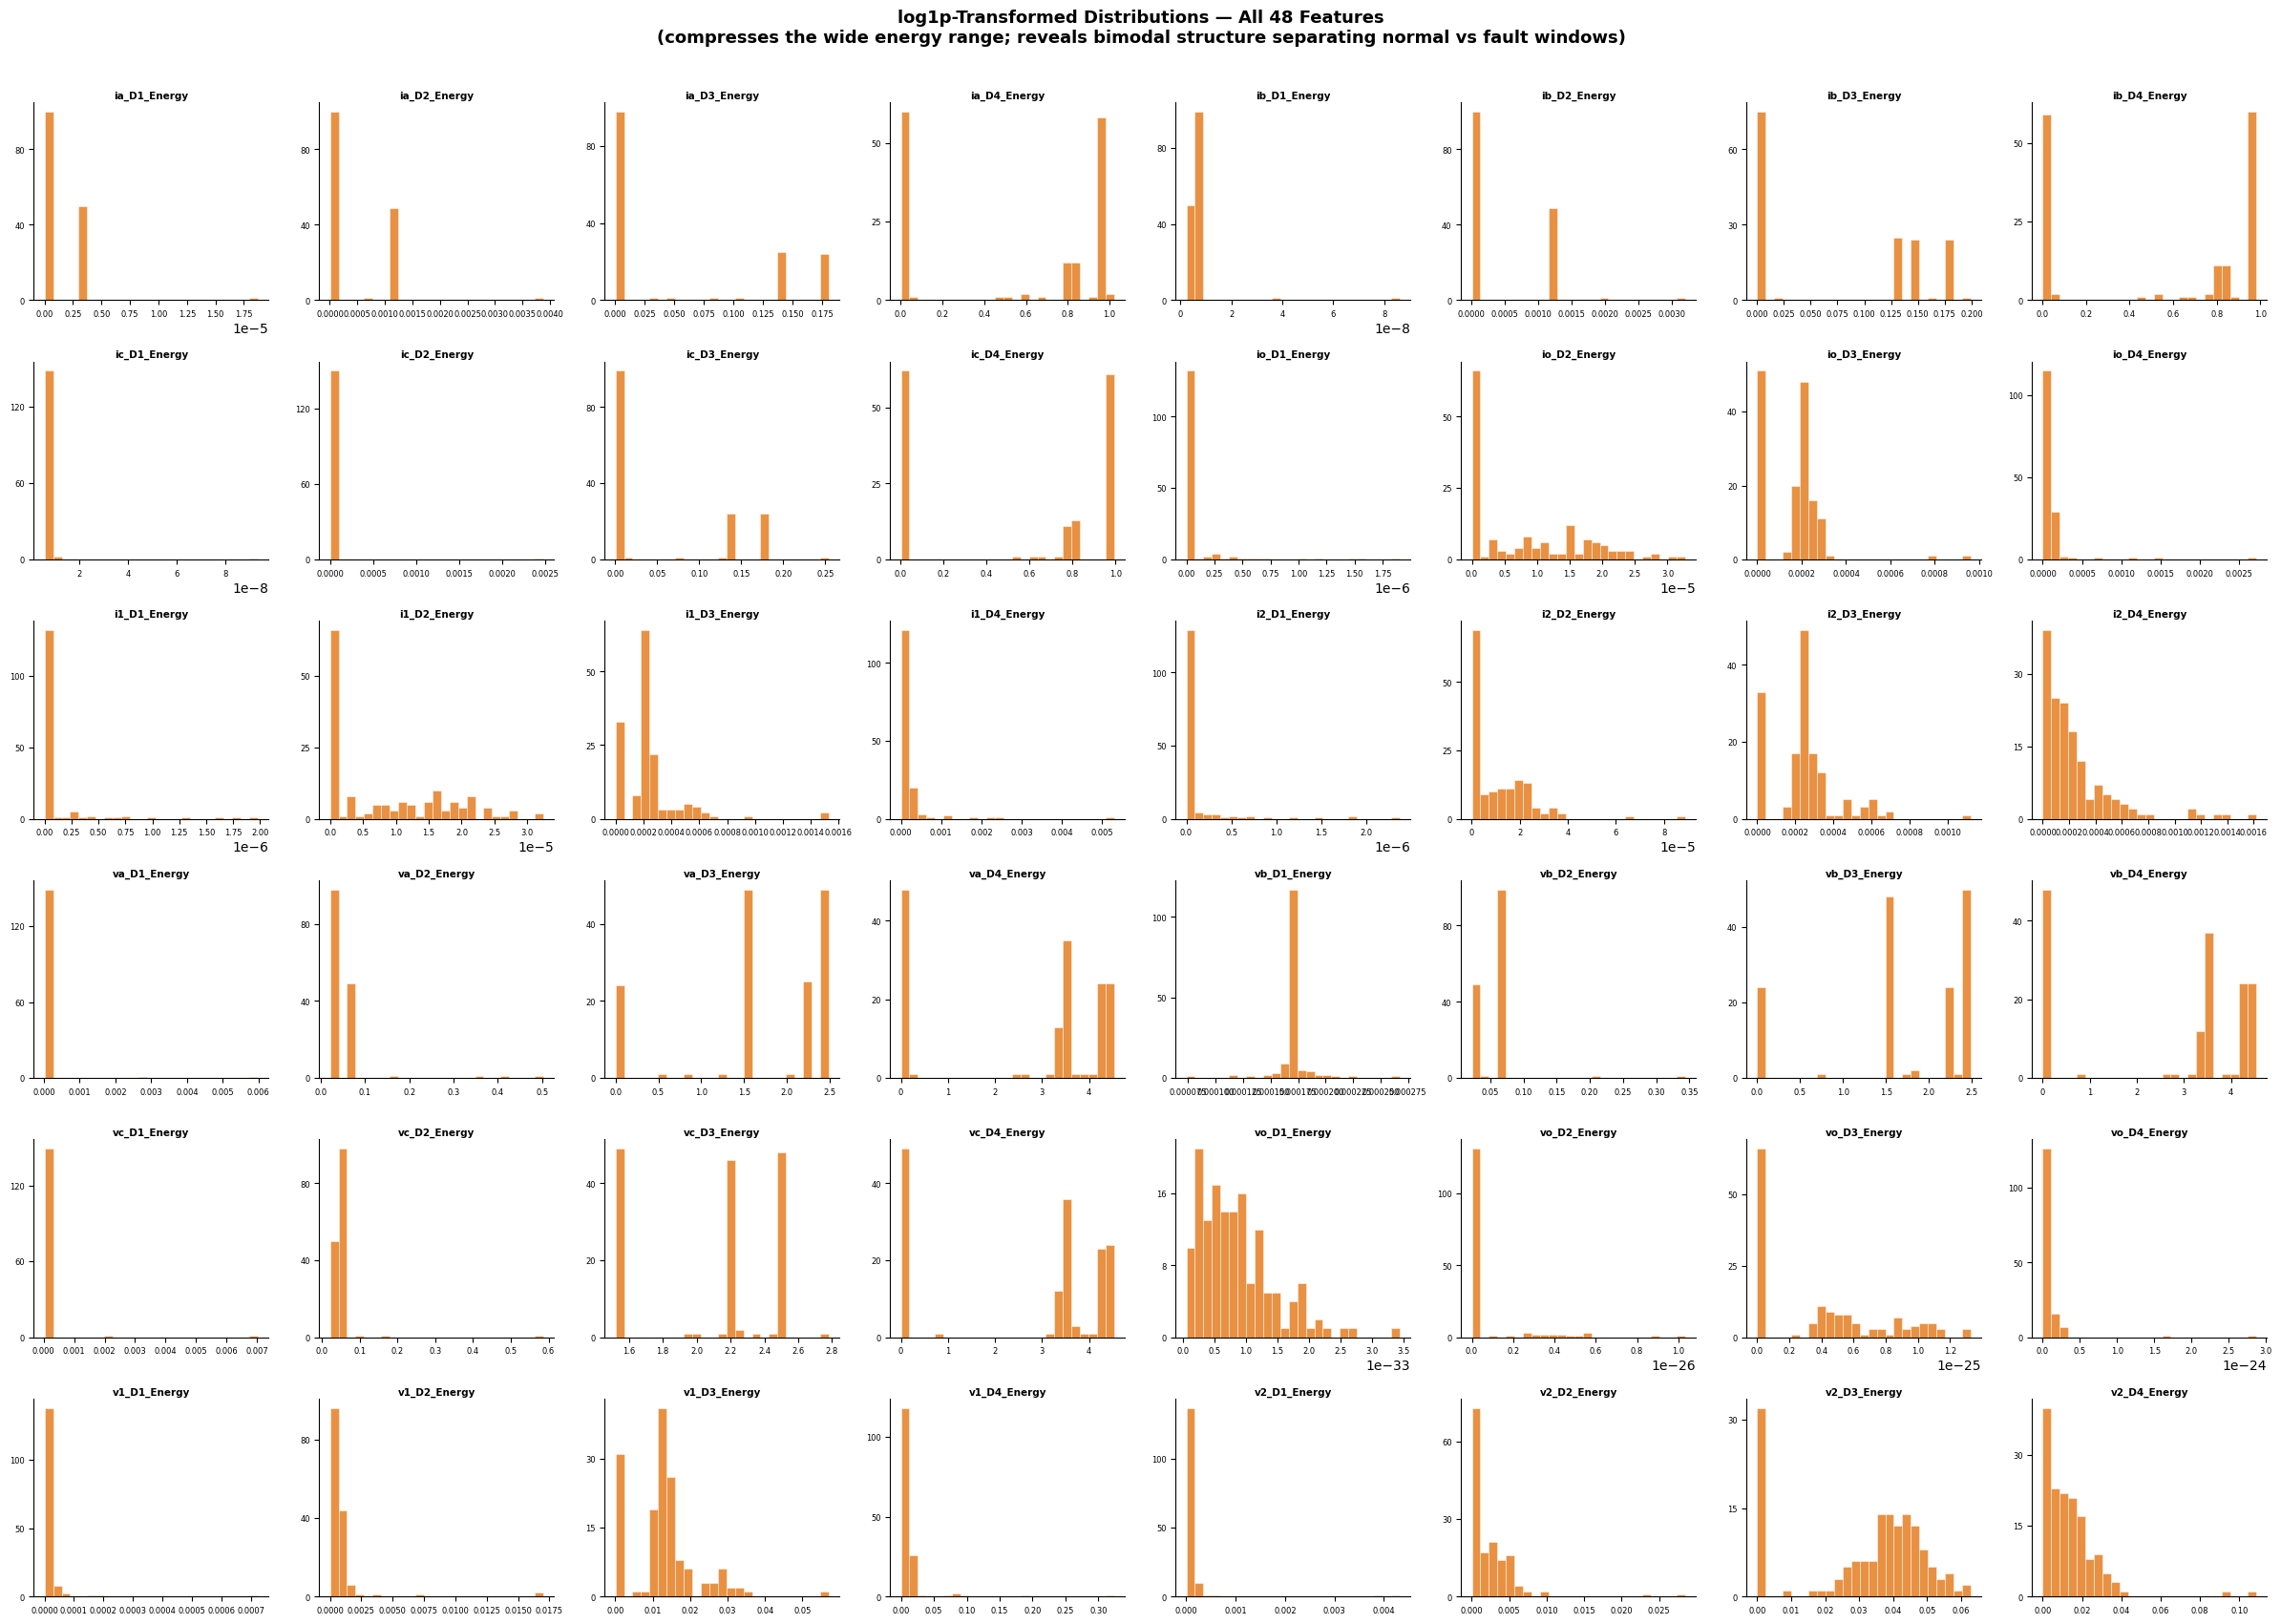

In [38]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    log_vals = np.log1p(df[col])
    axes[i].hist(log_vals, bins=25, color='#e67e22', edgecolor='white', linewidth=0.4, alpha=0.85)
    axes[i].set_title(col, fontsize=7.5, fontweight='bold', pad=3)
    axes[i].tick_params(labelsize=6)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(3))

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('log1p-Transformed Distributions — All 48 Features\n(compresses the wide energy range; reveals bimodal structure separating normal vs fault windows)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. KDE Plots — Smooth Density Curves per Feature

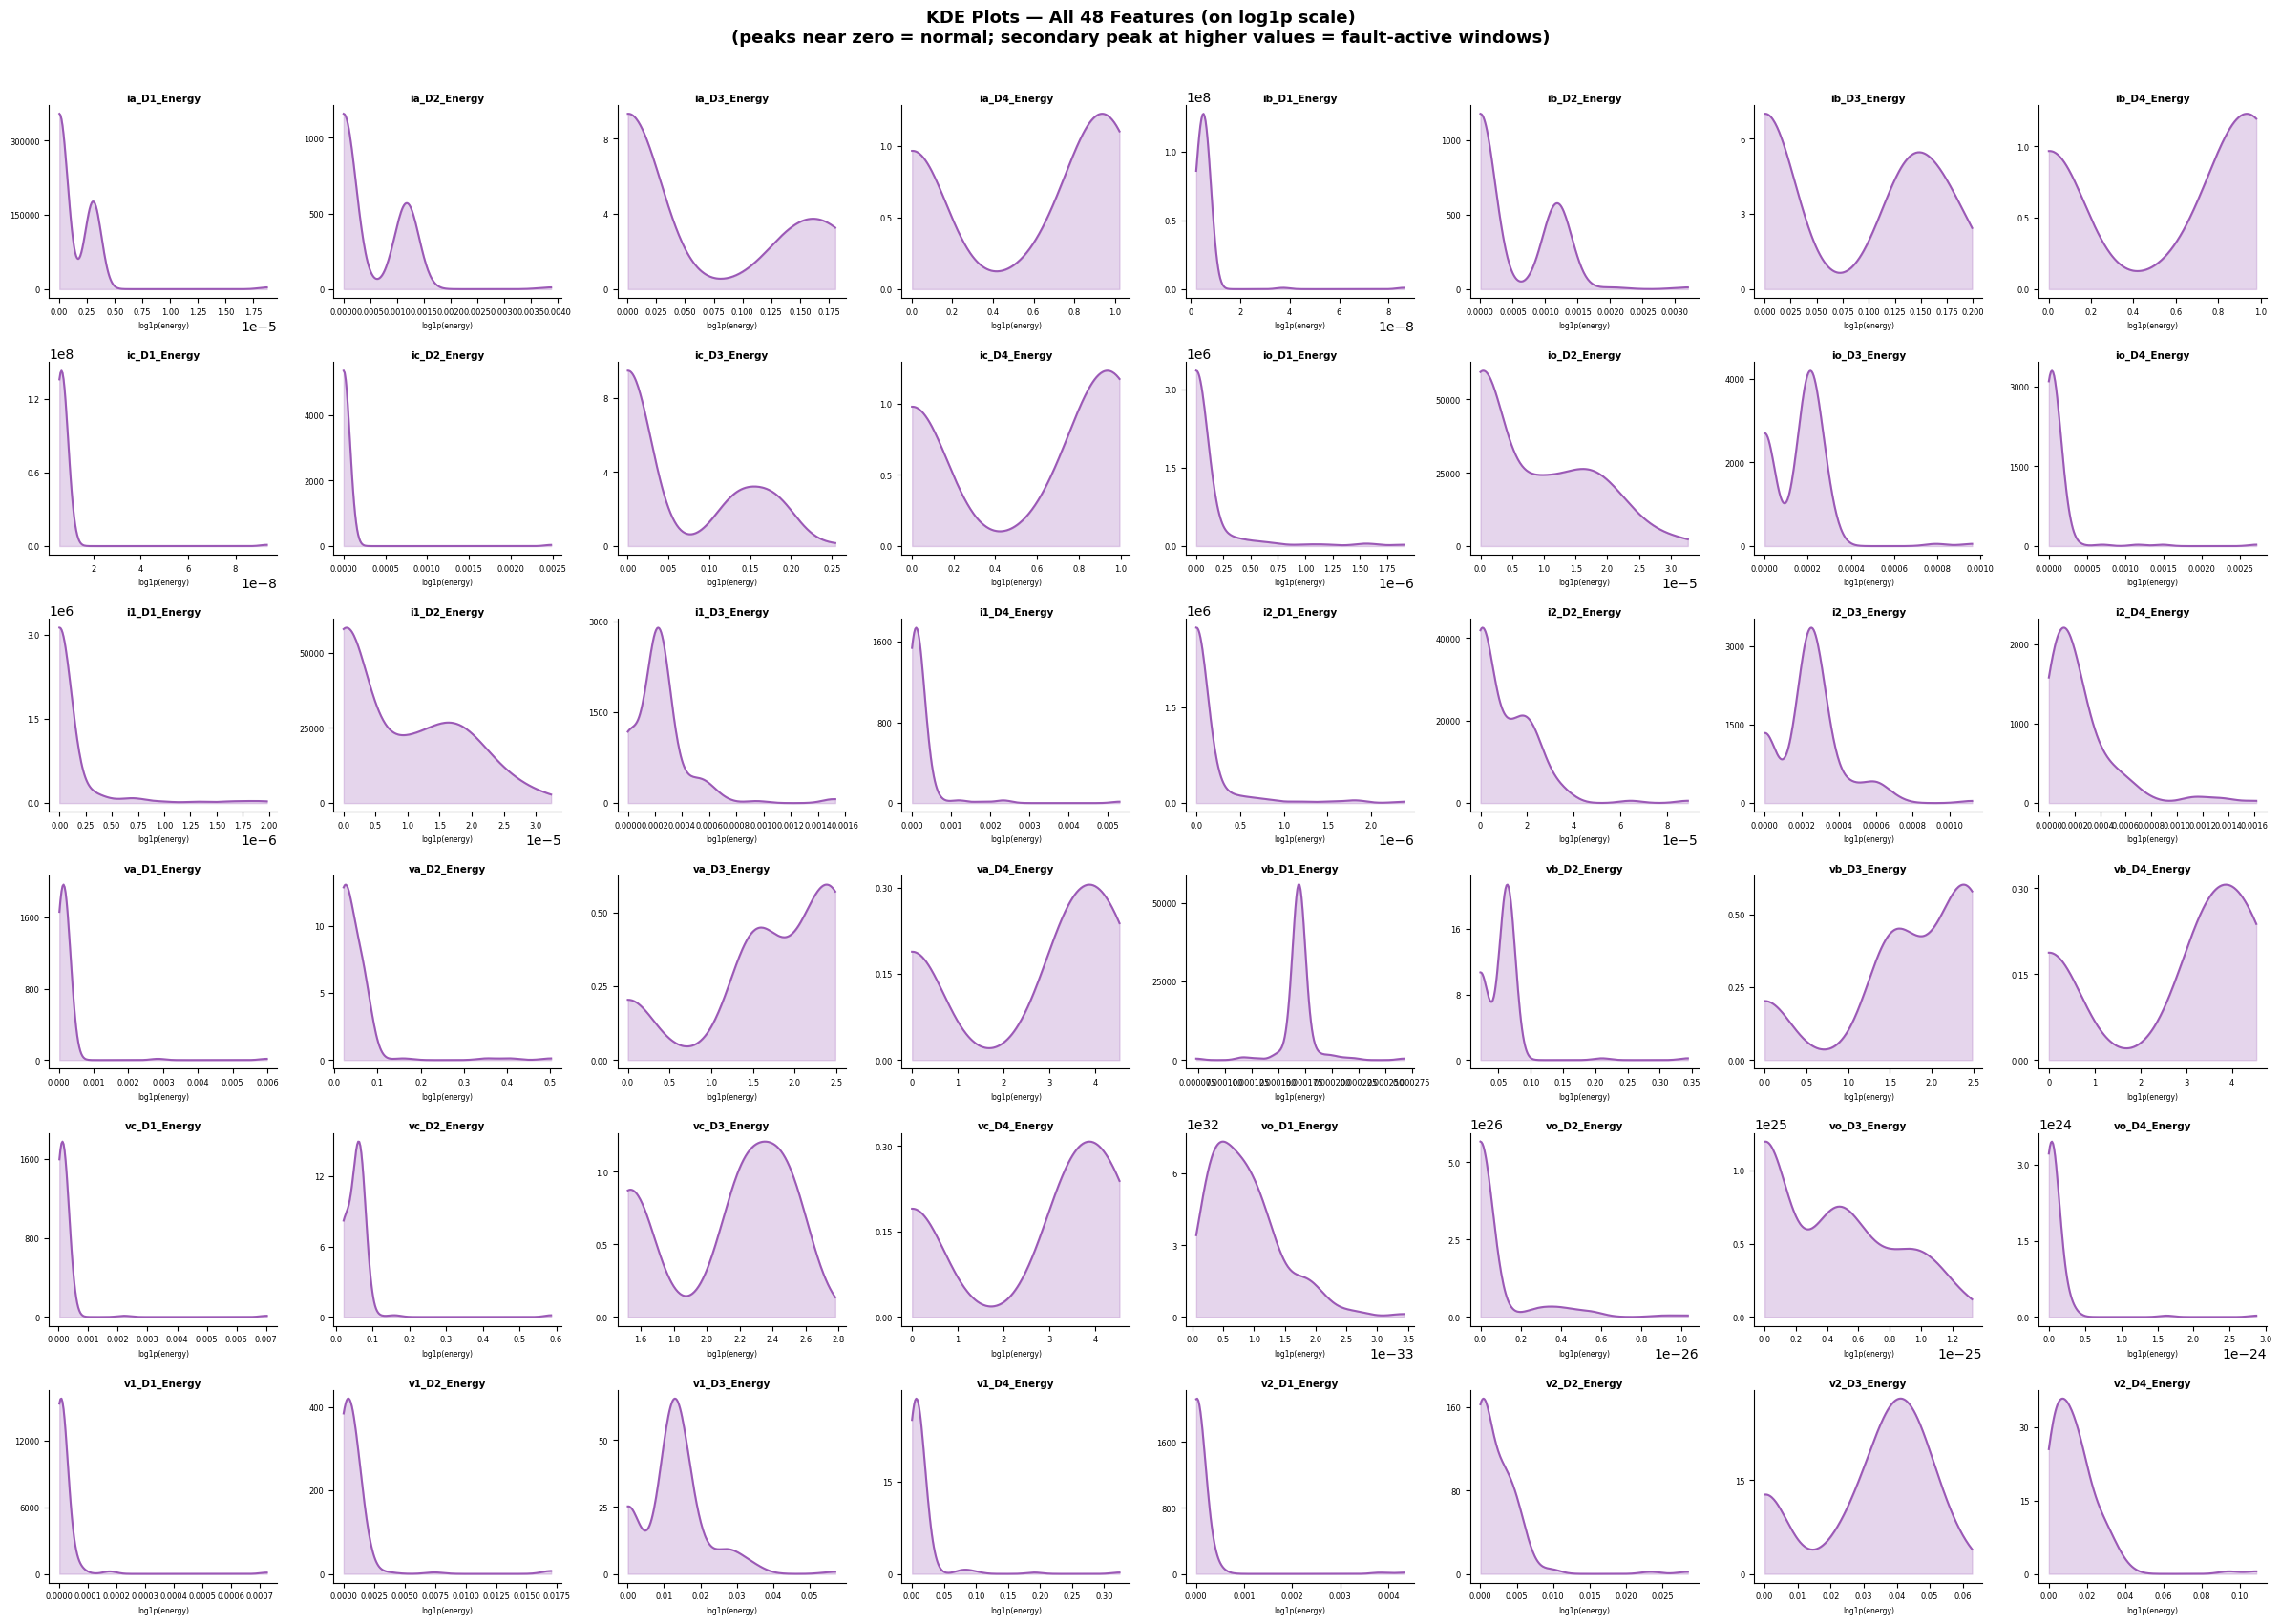

In [41]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    log_vals = np.log1p(df[col].values)
    x_grid = np.linspace(log_vals.min(), log_vals.max(), 200)
    kde = gaussian_kde(log_vals, bw_method='scott')
    axes[i].plot(x_grid, kde(x_grid), color='#9b59b6', linewidth=1.5)
    axes[i].fill_between(x_grid, kde(x_grid), alpha=0.25, color='#9b59b6')
    axes[i].set_title(col, fontsize=7.5, fontweight='bold', pad=3)
    axes[i].tick_params(labelsize=6)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(3))
    axes[i].set_xlabel('log1p(energy)', fontsize=5.5)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('KDE Plots — All 48 Features (on log1p scale)\n(peaks near zero = normal; secondary peak at higher values = fault-active windows)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Box Plots per Fault Class — Class Separation per Feature

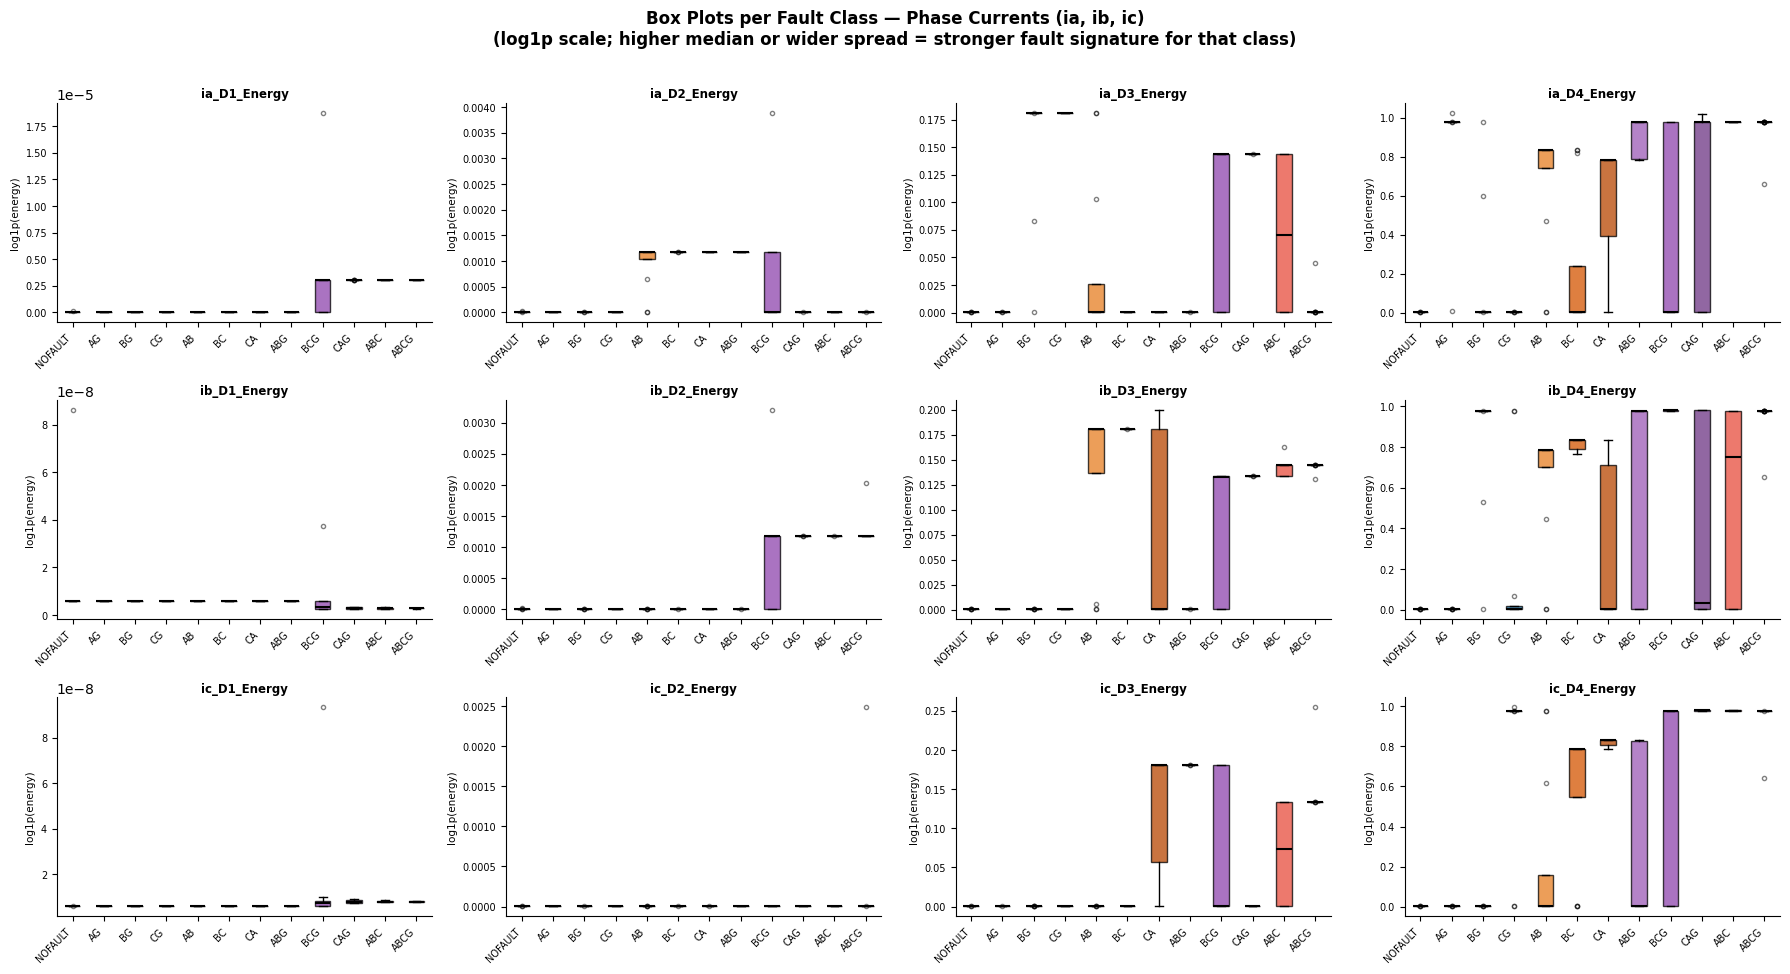

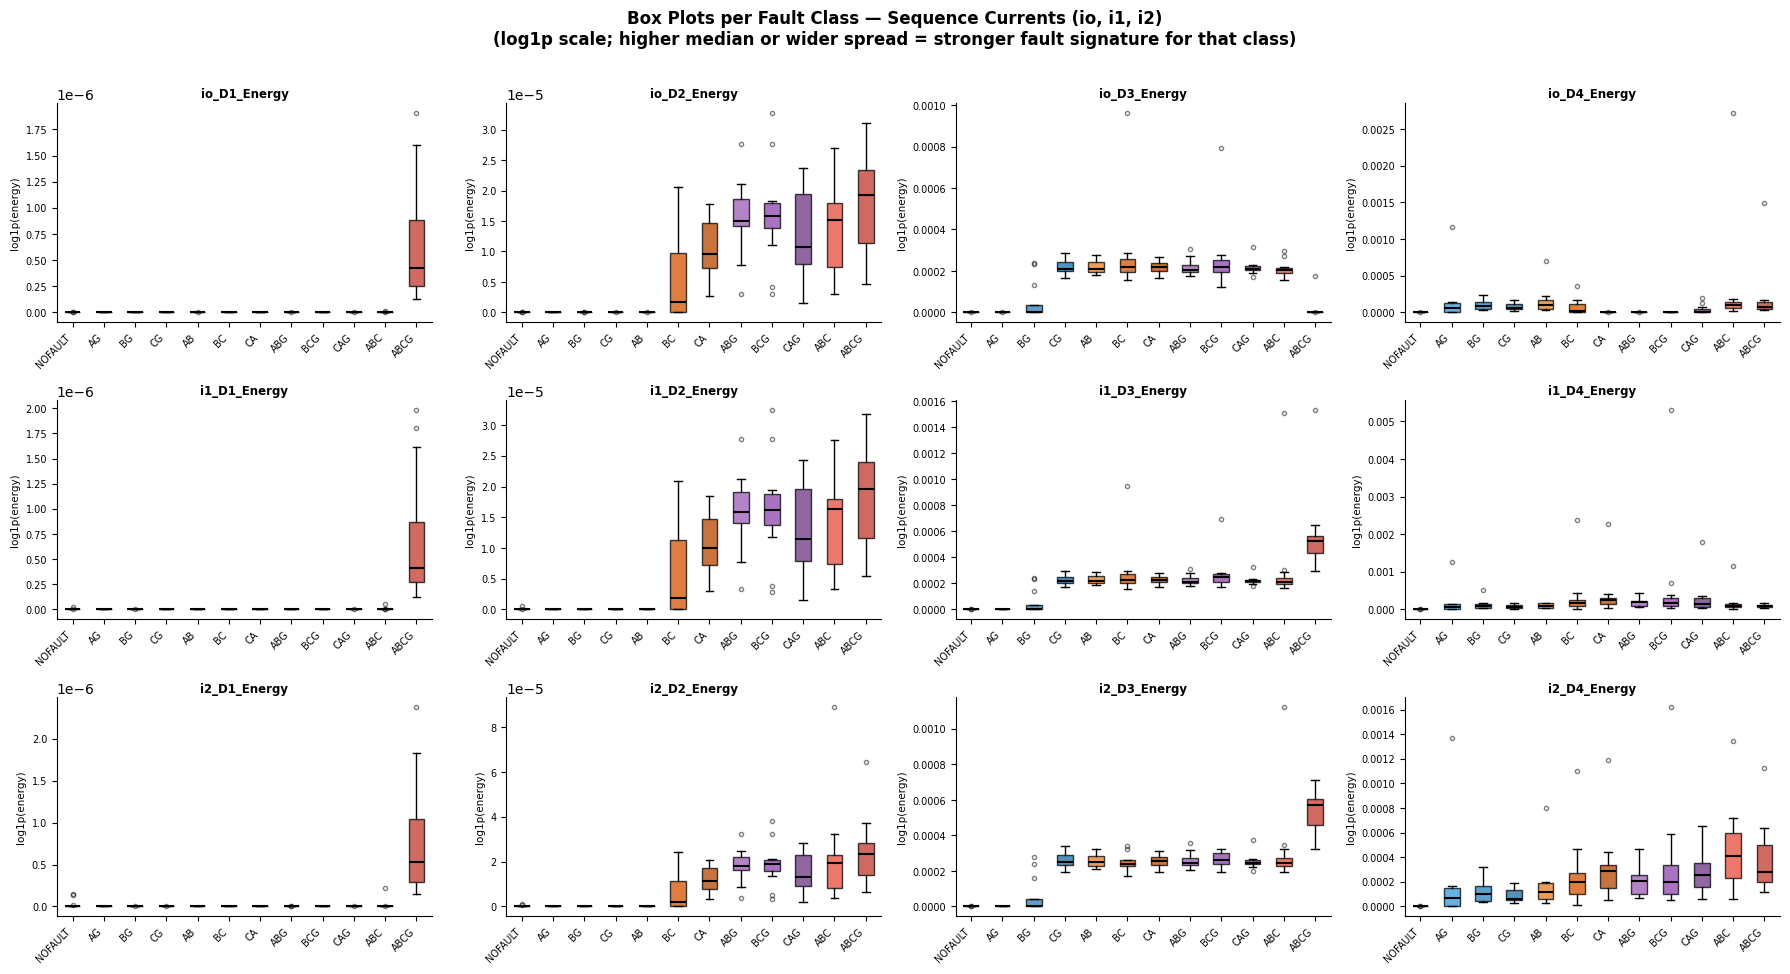

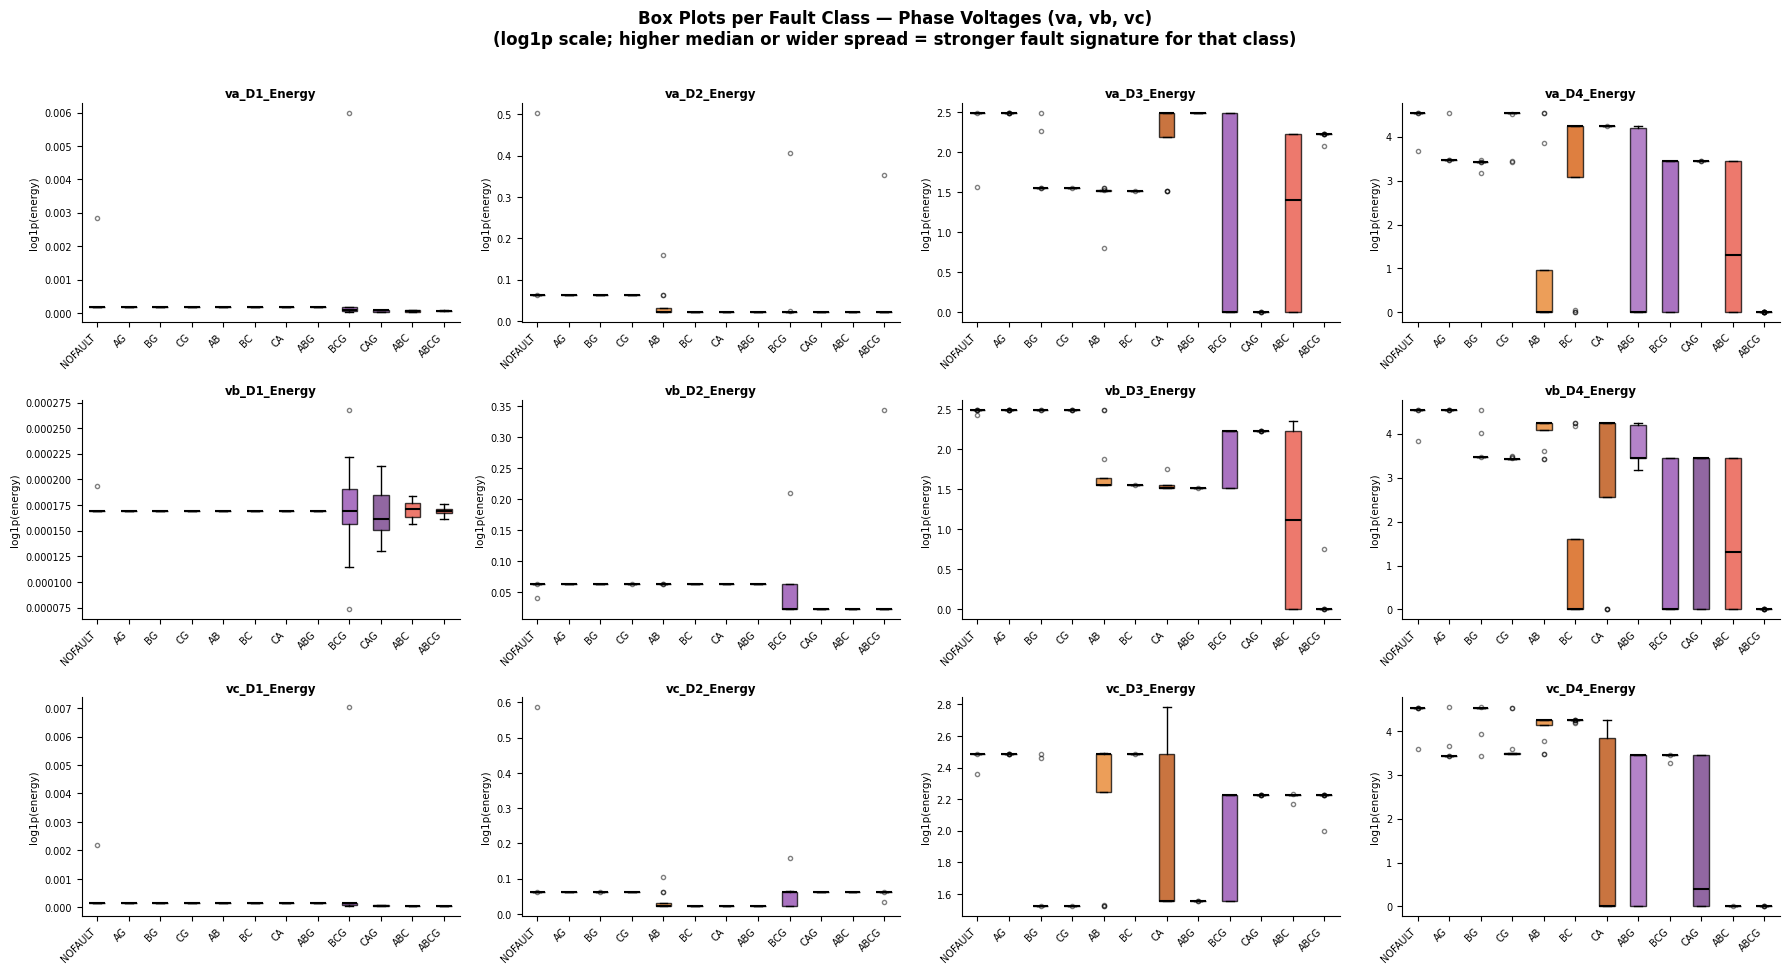

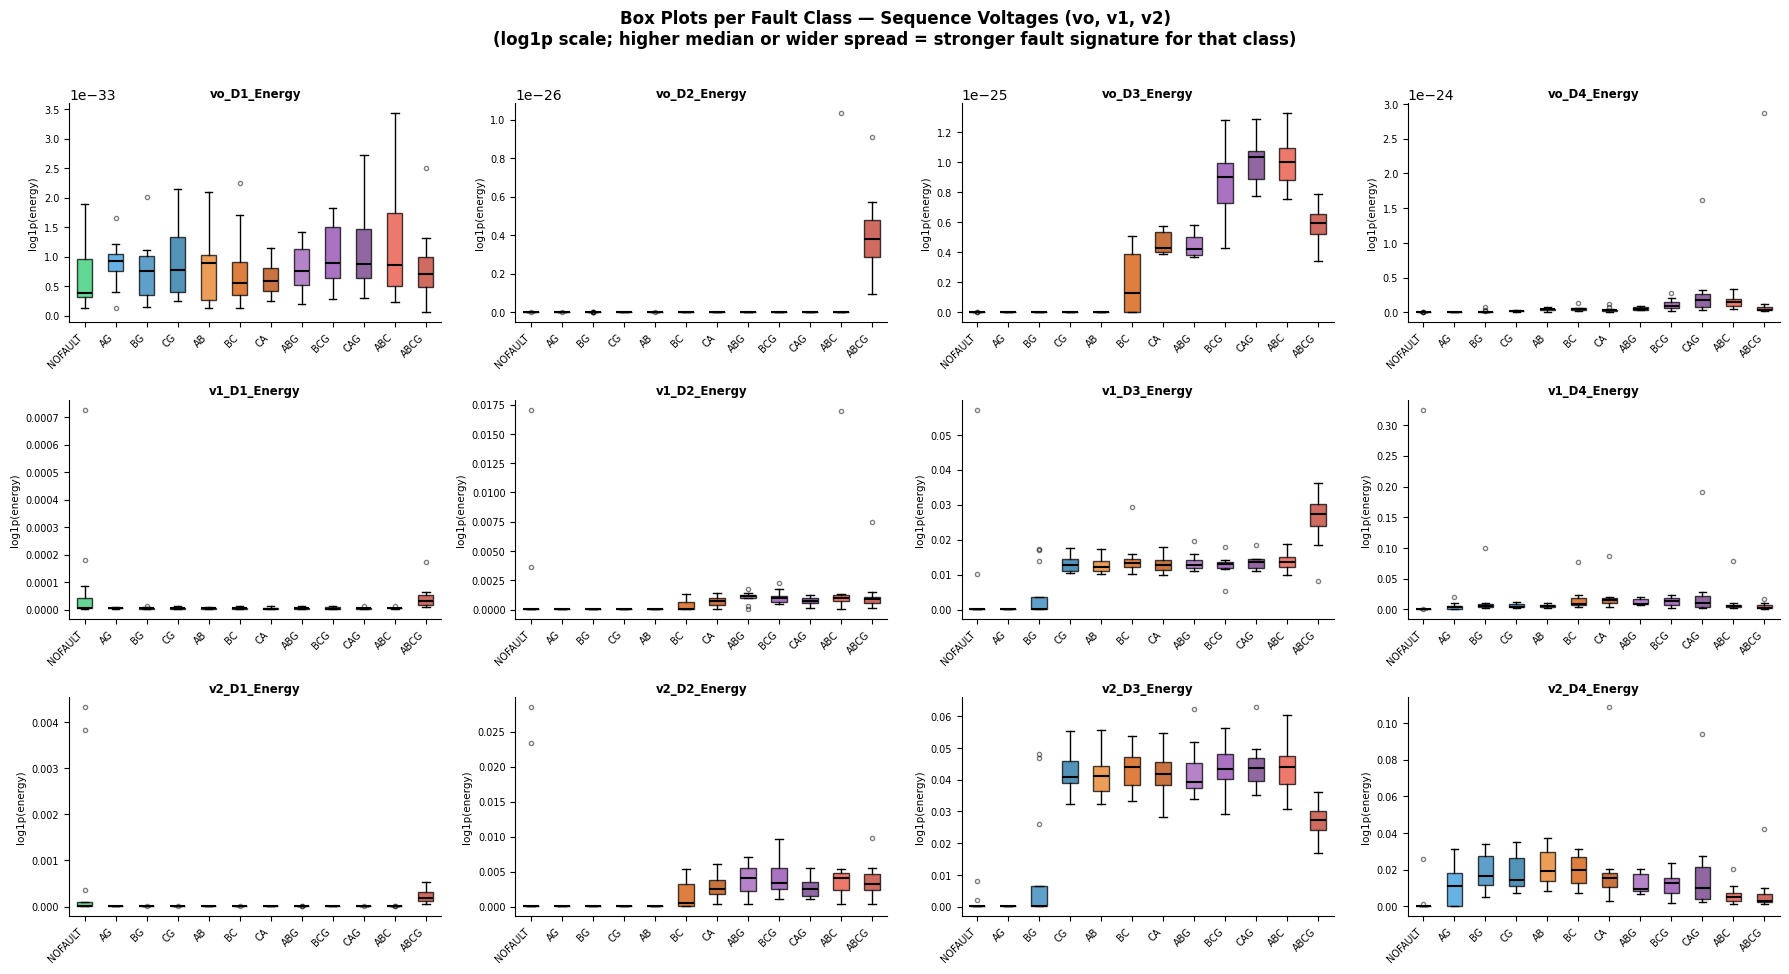

In [42]:
fault_order = ['NOFAULT', 'AG', 'BG', 'CG', 'AB', 'BC', 'CA', 'ABG', 'BCG', 'CAG', 'ABC', 'ABCG']
color_map = {
    'NOFAULT': '#2ecc71',
    'AG': '#3498db', 'BG': '#2980b9', 'CG': '#1a6fa0',
    'AB': '#e67e22', 'BC': '#d35400', 'CA': '#b84600',
    'ABG': '#9b59b6', 'BCG': '#8e44ad', 'CAG': '#6c3483',
    'ABC': '#e74c3c', 'ABCG': '#c0392b'
}
box_colors = [color_map[f] for f in fault_order]

signal_groups = {
    'Phase Currents (ia, ib, ic)':    ['ia', 'ib', 'ic'],
    'Sequence Currents (io, i1, i2)': ['io', 'i1', 'i2'],
    'Phase Voltages (va, vb, vc)':    ['va', 'vb', 'vc'],
    'Sequence Voltages (vo, v1, v2)': ['vo', 'v1', 'v2'],
}
levels = ['D1', 'D2', 'D3', 'D4']

for group_title, signals in signal_groups.items():
    fig, axes = plt.subplots(len(signals), len(levels), figsize=(18, len(signals) * 3.2))

    for row, sig in enumerate(signals):
        for col, lvl in enumerate(levels):
            ax = axes[row][col]
            col_name = f'{sig}_{lvl}_Energy'
            data_by_class = [np.log1p(df.loc[df['Fault_Label'] == cls, col_name].values)
                             for cls in fault_order]
            bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                            medianprops=dict(color='black', linewidth=1.5),
                            whiskerprops=dict(linewidth=1),
                            capprops=dict(linewidth=1),
                            flierprops=dict(marker='o', markersize=3, alpha=0.5))
            for patch, c in zip(bp['boxes'], box_colors):
                patch.set_facecolor(c)
                patch.set_alpha(0.75)

            ax.set_title(col_name, fontsize=8.5, fontweight='bold', pad=4)
            ax.set_xticks(range(1, len(fault_order) + 1))
            ax.set_xticklabels(fault_order, rotation=45, ha='right', fontsize=7)
            ax.set_ylabel('log1p(energy)', fontsize=7.5)
            ax.tick_params(axis='y', labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle(f'Box Plots per Fault Class — {group_title}\n(log1p scale; higher median or wider spread = stronger fault signature for that class)',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# EDA — Correlation & Redundancy Analysis

## 1. Full Correlation Heatmap (48 × 48)

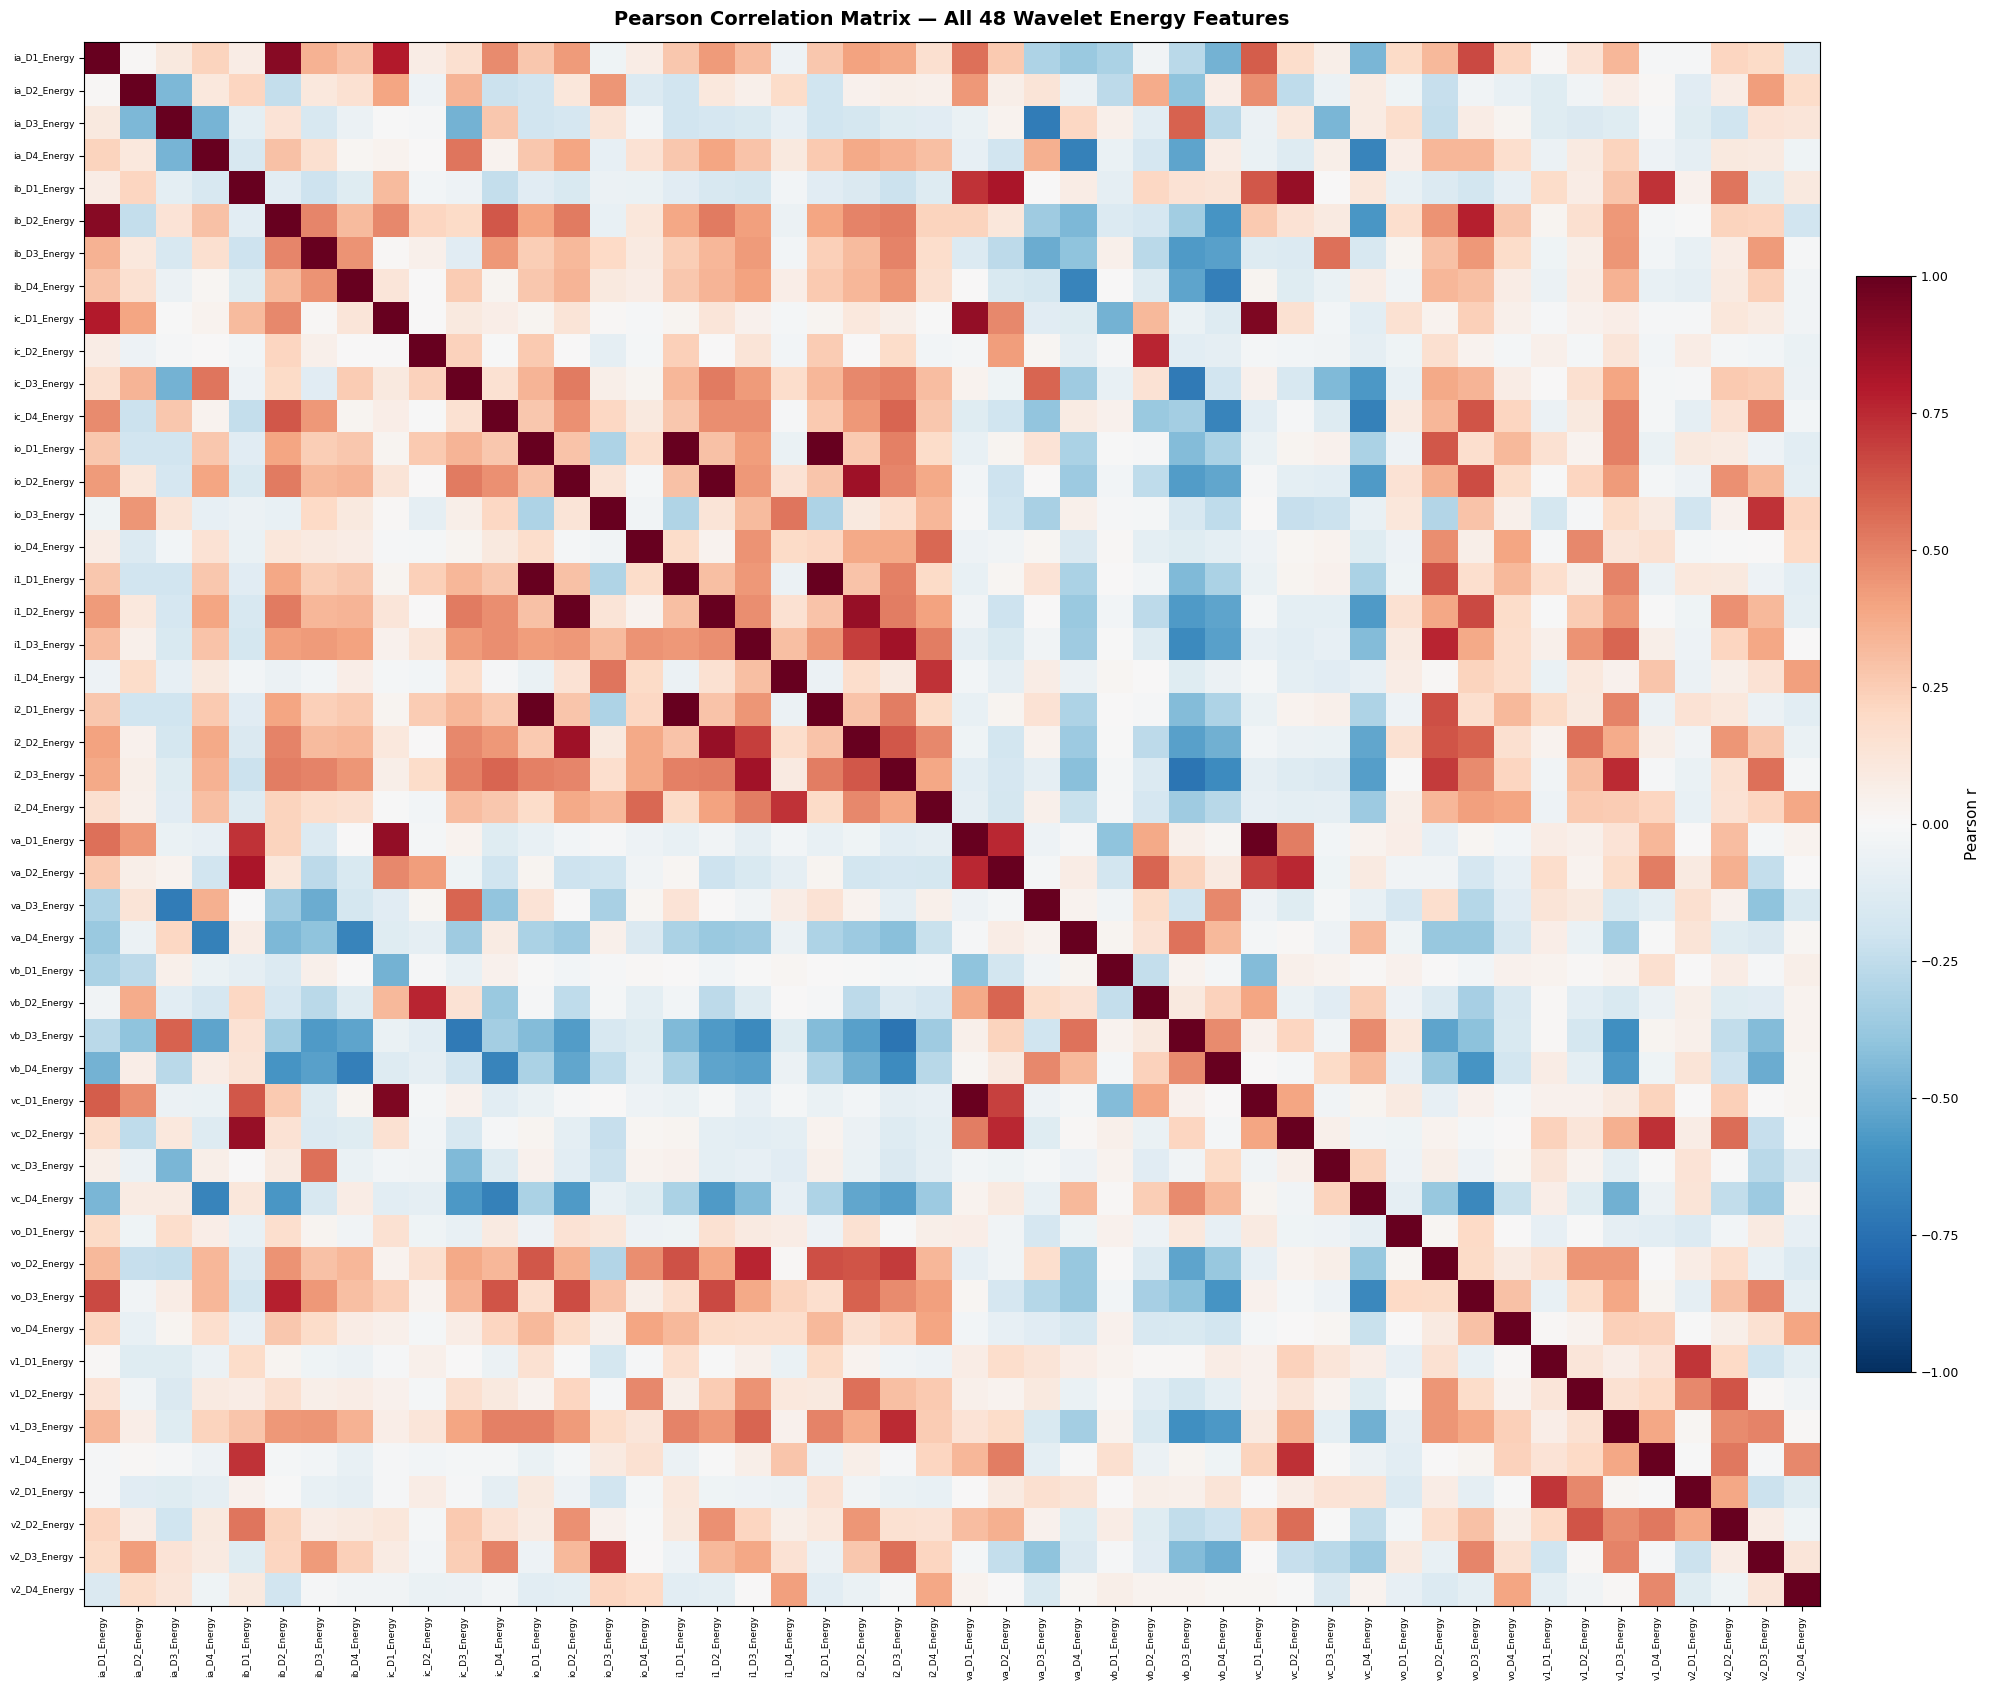

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

feature_cols = [c for c in df.columns if c.endswith('_Energy')]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(20, 17))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=6.5)
ax.set_yticklabels(feature_cols, fontsize=6.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Pearson r', fontsize=11)
cbar.ax.tick_params(labelsize=9)

ax.set_title('Pearson Correlation Matrix — All 48 Wavelet Energy Features', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 2. Highly Correlated Feature Pairs (|r| ≥ 0.95)

Feature pairs with |r| >= 0.95: 5 found

      Feature_A     Feature_B  Pearson_r
#                                       
1  io_D1_Energy  i1_D1_Energy     0.9977
2  io_D2_Energy  i1_D2_Energy     0.9970
3  io_D1_Energy  i2_D1_Energy     0.9956
4  i1_D1_Energy  i2_D1_Energy     0.9943
5  va_D1_Energy  vc_D1_Energy     0.9890


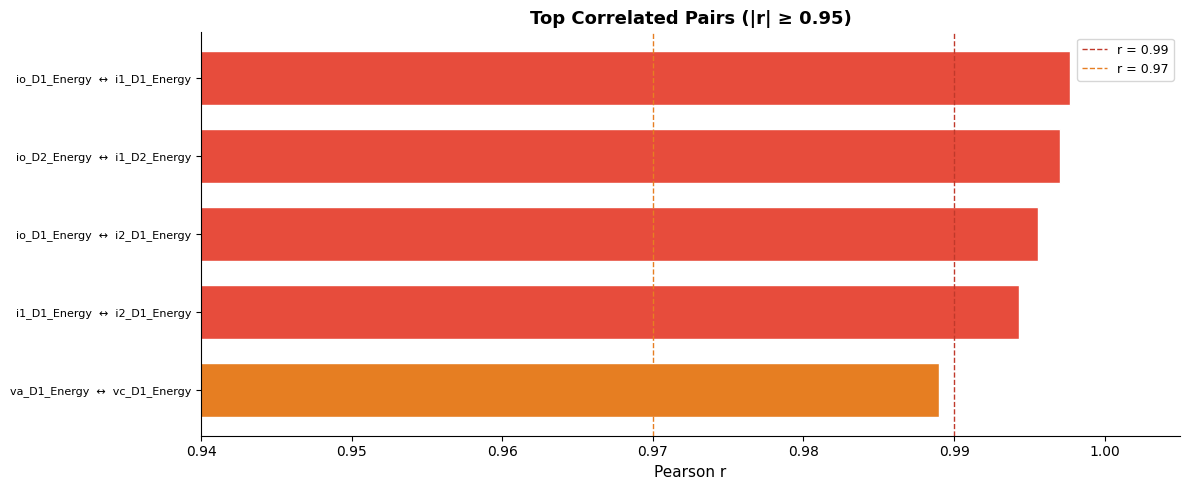

In [44]:
THRESHOLD = 0.95

# Extract upper triangle pairs
pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        r = corr.iloc[i, j]
        if abs(r) >= THRESHOLD:
            pairs.append({'Feature_A': feature_cols[i], 'Feature_B': feature_cols[j], 'Pearson_r': round(r, 4)})

pairs_df = pd.DataFrame(pairs).sort_values('Pearson_r', ascending=False).reset_index(drop=True)
pairs_df.index += 1
pairs_df.index.name = '#'

print(f"Feature pairs with |r| >= {THRESHOLD}: {len(pairs_df)} found\n")
print(pairs_df.to_string())

# Bar chart of top 30 most correlated pairs
top = pairs_df.head(30)
fig, ax = plt.subplots(figsize=(12, max(5, len(top) * 0.35)))
bar_colors = ['#e74c3c' if r >= 0.99 else '#e67e22' if r >= 0.97 else '#f1c40f' for r in top['Pearson_r']]
ax.barh(range(len(top)), top['Pearson_r'], color=bar_colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f"{row.Feature_A}  ↔  {row.Feature_B}" for _, row in top.iterrows()], fontsize=8)
ax.set_xlim(THRESHOLD - 0.01, 1.005)
ax.axvline(x=0.99, color='#c0392b', linestyle='--', linewidth=1, label='r = 0.99')
ax.axvline(x=0.97, color='#e67e22', linestyle='--', linewidth=1, label='r = 0.97')
ax.set_xlabel('Pearson r', fontsize=11)
ax.set_title(f'Top Correlated Pairs (|r| ≥ {THRESHOLD})', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Redundant Feature Identification — Greedy Drop Strategy

In [45]:
# Greedy approach: for each high-corr pair, mark the second feature as redundant
# (keeps the first encountered; can be adjusted based on domain knowledge)
to_drop = set()
for _, row in pairs_df.iterrows():
    if row['Feature_A'] not in to_drop:
        to_drop.add(row['Feature_B'])

kept    = [f for f in feature_cols if f not in to_drop]
dropped = [f for f in feature_cols if f in to_drop]

print(f"Original features : {len(feature_cols)}")
print(f"Redundant (drop)  : {len(dropped)}")
print(f"Retained (keep)   : {len(kept)}")
print()
print("--- Features to DROP (highly correlated with a retained feature) ---")
for f in dropped:
    # Find what it is correlated with
    partners = pairs_df[(pairs_df['Feature_B'] == f)]['Feature_A'].tolist()
    print(f"  {f:<25s}  r={corr.loc[f, partners[0]]:.4f} with {partners[0]}")
print()
print("--- Features to KEEP ---")
for f in kept:
    print(f"  {f}")

Original features : 48
Redundant (drop)  : 4
Retained (keep)   : 44

--- Features to DROP (highly correlated with a retained feature) ---
  i1_D1_Energy               r=0.9977 with io_D1_Energy
  i1_D2_Energy               r=0.9970 with io_D2_Energy
  i2_D1_Energy               r=0.9956 with io_D1_Energy
  vc_D1_Energy               r=0.9890 with va_D1_Energy

--- Features to KEEP ---
  ia_D1_Energy
  ia_D2_Energy
  ia_D3_Energy
  ia_D4_Energy
  ib_D1_Energy
  ib_D2_Energy
  ib_D3_Energy
  ib_D4_Energy
  ic_D1_Energy
  ic_D2_Energy
  ic_D3_Energy
  ic_D4_Energy
  io_D1_Energy
  io_D2_Energy
  io_D3_Energy
  io_D4_Energy
  i1_D3_Energy
  i1_D4_Energy
  i2_D2_Energy
  i2_D3_Energy
  i2_D4_Energy
  va_D1_Energy
  va_D2_Energy
  va_D3_Energy
  va_D4_Energy
  vb_D1_Energy
  vb_D2_Energy
  vb_D3_Energy
  vb_D4_Energy
  vc_D2_Energy
  vc_D3_Energy
  vc_D4_Energy
  vo_D1_Energy
  vo_D2_Energy
  vo_D3_Energy
  vo_D4_Energy
  v1_D1_Energy
  v1_D2_Energy
  v1_D3_Energy
  v1_D4_Energy
  v2_D1_Ener

## 4. Reduced Feature Set Correlation Heatmap

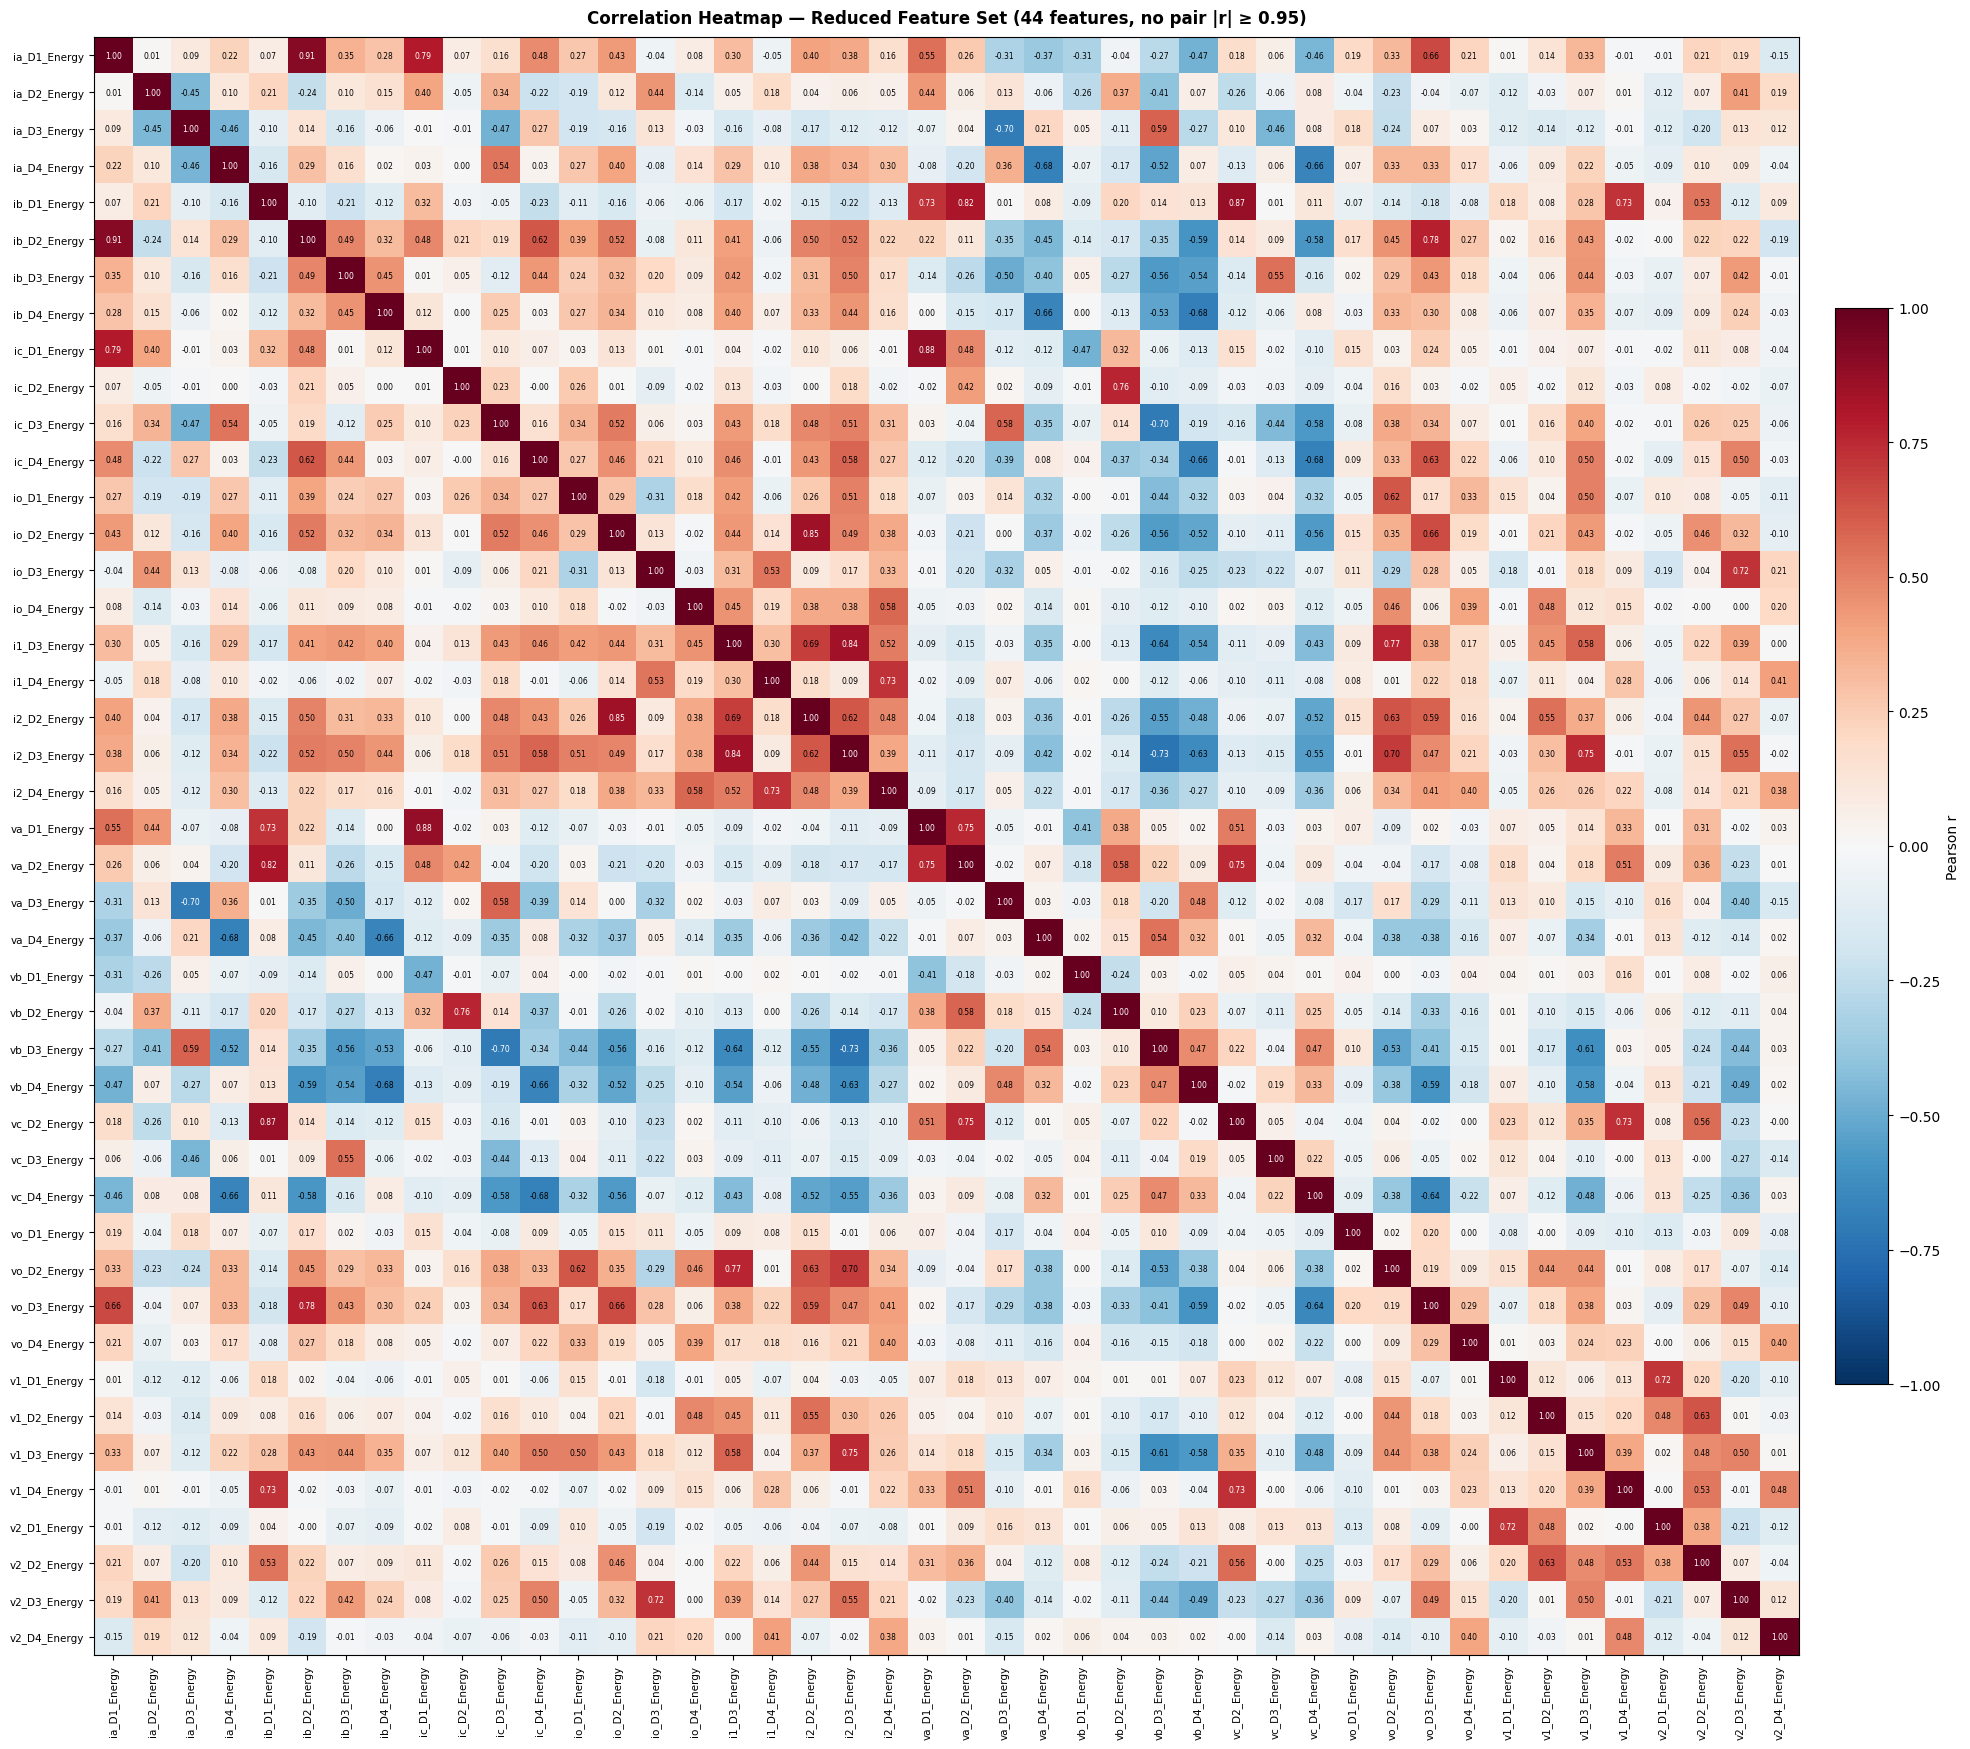

In [46]:
corr_reduced = df[kept].corr()

fig, ax = plt.subplots(figsize=(max(10, len(kept) * 0.45), max(8, len(kept) * 0.4)))
im = ax.imshow(corr_reduced.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(kept)))
ax.set_yticks(range(len(kept)))
ax.set_xticklabels(kept, rotation=90, fontsize=7.5)
ax.set_yticklabels(kept, fontsize=7.5)

# Annotate cells with r value
for i in range(len(kept)):
    for j in range(len(kept)):
        val = corr_reduced.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=5.5, color='black' if abs(val) < 0.7 else 'white')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Pearson r', fontsize=10)
ax.set_title(f'Correlation Heatmap — Reduced Feature Set ({len(kept)} features, no pair |r| ≥ {THRESHOLD})',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## 5. Within-Group Correlation — Same-Level Cross-Phase & Cross-Signal

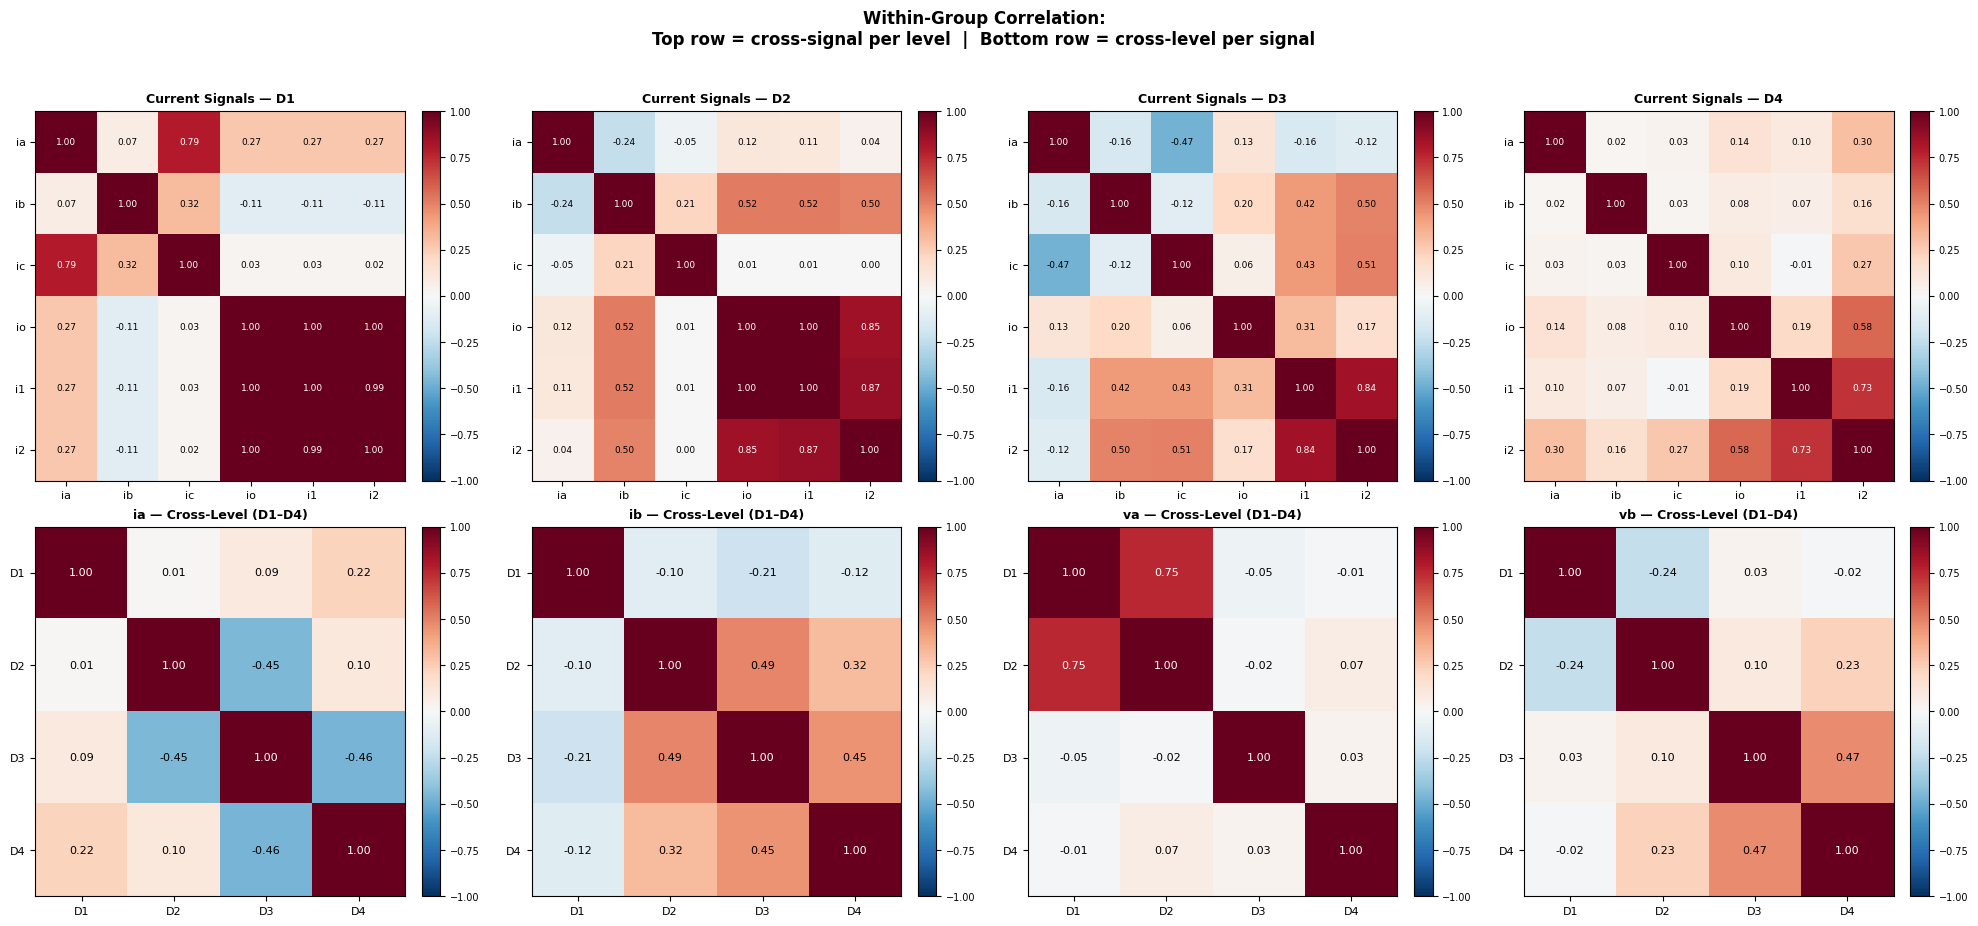

In [47]:
# Compare cross-phase correlation per level and cross-level per signal
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

# Row 0: cross-phase correlation per level (ia vs ib vs ic, va vs vb vs vc)
for col_idx, lvl in enumerate(['D1', 'D2', 'D3', 'D4']):
    curr_feats = [f'ia_{lvl}_Energy', f'ib_{lvl}_Energy', f'ic_{lvl}_Energy',
                  f'io_{lvl}_Energy', f'i1_{lvl}_Energy', f'i2_{lvl}_Energy']
    sub_corr = df[curr_feats].corr()
    ax = axes[0][col_idx]
    im = ax.imshow(sub_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    labels = ['ia', 'ib', 'ic', 'io', 'i1', 'i2']
    ax.set_xticks(range(6)); ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks(range(6)); ax.set_yticklabels(labels, fontsize=8)
    for i in range(6):
        for j in range(6):
            ax.text(j, i, f'{sub_corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6.5,
                    color='white' if abs(sub_corr.iloc[i,j]) > 0.6 else 'black')
    ax.set_title(f'Current Signals — {lvl}', fontsize=9, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=7)

# Row 1: cross-level correlation per signal (D1 vs D2 vs D3 vs D4 for ia, va)
for col_idx, sig in enumerate(['ia', 'ib', 'va', 'vb']):
    lvl_feats = [f'{sig}_{l}_Energy' for l in ['D1', 'D2', 'D3', 'D4']]
    sub_corr = df[lvl_feats].corr()
    ax = axes[1][col_idx]
    im = ax.imshow(sub_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(['D1','D2','D3','D4'], fontsize=8)
    ax.set_yticks(range(4)); ax.set_yticklabels(['D1','D2','D3','D4'], fontsize=8)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{sub_corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(sub_corr.iloc[i,j]) > 0.6 else 'black')
    ax.set_title(f'{sig} — Cross-Level (D1–D4)', fontsize=9, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=7)

fig.suptitle('Within-Group Correlation:\nTop row = cross-signal per level  |  Bottom row = cross-level per signal',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()